# Road Trip Cost Prediction — ML Project

**By Param Kotadiya** · Semester 5 · Machine Learning

**Problem Statement:** Given the details of a road trip (route, vehicle, fuel, traffic, weather, etc.), predict the **total trip cost** using Machine Learning.

**Dataset Source:** `road_trip_data.csv`

**Target Variable:** `total_trip_cost`

**Type of Problem:** Regression (predicting a continuous numeric value), with two supporting
classification tasks added in Week 7.

---

### Contents

| Week | What it covers |
|---|---|
| 1 | Problem definition and dataset exploration |
| 2 | Data preprocessing — missing values, duplicates, outliers, encoding, scaling, visualisation |
| 3 | Linear regression: sklearn `fit()` **and** gradient descent written from scratch |
| 4 | The dataset is synthetic — recovering the cost formula that generated it |
| 5 | Scaling from 9 fixed routes to 537 real Indian cities |
| 6 | One engineered feature beats two ensemble models |
| 7 | Classification — and being honest about which of the two targets is real |
| 8 | Why gradient descent stopped converging, and why Ridge was the wrong fix |
| **9** | **Task 5 — evaluation, validation, cross-validation and hyperparameter tuning** |
| **10** | **Removing the magic numbers: a chained model pipeline** |

Weeks 9 and 10 are the current work. Week 9 answers the Task 5 checklist in full (the
consolidated tables are also in [`TASK5.md`](TASK5.md)); Week 10 rebuilds the prediction path so
that every intermediate value — road distance, mileage, litres, toll, traffic — comes from a
fitted sub-model instead of a hardcoded constant, and measures what that costs.

**The one result to take away:** the R² of 0.9997 reported in Weeks 6–8 is real but was measured
with the true toll, parking and litres supplied as input features. A traveller supplies none of
those. Predicting from what a user actually knows gives **R² 0.9645, MAE ₹391** — and that is the
figure the deployed application reports.

## Week 1: Problem Definition and Dataset Exploration

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)


### 1.1 Load the Dataset

In [2]:
df = pd.read_csv('road_trip_data.csv')
df.head()

,start_city,destination_city,distance_km,vehicle_type,fuel_type,mileage,fuel_price,passengers,departure_hour,traffic_level,weather_condition,toll_cost,parking_cost,estimated_time_minutes,fuel_consumption_litres,total_trip_cost
0,Bengaluru,Mysuru,148.27,Sedan,Petrol,15.67,94.89,5,19,Medium,Cloudy,252.47,120.0,173.91,9.677,1393.39
1,Rajkot,Ahmedabad,215.59,Hatchback,Diesel,21.43,97.64,1,9,Medium,Clear,217.57,60.0,233.59,10.641,1435.61
2,Ahmedabad,Vadodara,118.93,SUV,CNG,9.79,83.65,3,19,Medium,Clear,113.29,40.0,118.00,12.956,1345.60
3,Rajkot,Ahmedabad,225.28,SUV,Diesel,13.16,88.54,4,5,Medium,Clear,341.60,80.0,256.44,17.970,2187.79
4,Rajkot,Ahmedabad,223.63,SUV,Petrol,8.77,95.26,3,18,Medium,Clear,221.95,80.0,252.12,26.428,2989.54


### 1.2 Problem Statement

Road trips involve many variable costs — fuel, tolls, parking — which depend on the route, vehicle type,
traffic conditions, weather, and driving time. Estimating this cost in advance is useful for trip planning
and budgeting.

**Goal:** Predict `total_trip_cost` using features such as `distance_km`, `vehicle_type`, `fuel_type`,
`mileage`, `fuel_price`, `passengers`, `departure_hour`, `traffic_level`, `weather_condition`, `toll_cost`,
`parking_cost`, `estimated_time_minutes`, and `fuel_consumption_litres`.


### 1.3 Dataset Summary

In [3]:
print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Shape of dataset (rows, columns): (1140, 16)

Column names:
['start_city', 'destination_city', 'distance_km', 'vehicle_type', 'fuel_type', 'mileage', 'fuel_price', 'passengers', 'departure_hour', 'traffic_level', 'weather_condition', 'toll_cost', 'parking_cost', 'estimated_time_minutes', 'fuel_consumption_litres', 'total_trip_cost']


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   start_city               1140 non-null   str    
 1   destination_city         1140 non-null   str    
 2   distance_km              1140 non-null   float64
 3   vehicle_type             1140 non-null   str    
 4   fuel_type                1140 non-null   str    
 5   mileage                  1140 non-null   float64
 6   fuel_price               1140 non-null   float64
 7   passengers               1140 non-null   int64  
 8   departure_hour           1140 non-null   int64  
 9   traffic_level            1140 non-null   str    
 10  weather_condition        1140 non-null   str    
 11  toll_cost                1140 non-null   float64
 12  parking_cost             1140 non-null   float64
 13  estimated_time_minutes   1140 non-null   float64
 14  fuel_consumption_litres  1140 non-n

In [5]:
df.describe()


,distance_km,mileage,fuel_price,passengers,departure_hour,toll_cost,parking_cost,estimated_time_minutes,fuel_consumption_litres,total_trip_cost
count,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000
mean,239.773570,15.454544,93.039860,3.067544,11.576316,303.641711,68.859649,246.833544,16.944999,2111.156140
std,85.064093,3.274084,8.958219,1.406681,6.868919,116.538561,45.323126,67.945709,6.894890,788.421313
min,110.130000,8.180000,72.130000,1.000000,0.000000,99.470000,0.000000,95.630000,5.111000,688.790000
25%,158.460000,12.975000,88.085000,2.000000,6.000000,215.750000,40.000000,203.995000,11.168500,1464.477500
50%,263.475000,15.465000,94.785000,3.000000,12.000000,289.565000,60.000000,254.250000,16.062000,2031.505000
75%,286.072500,17.912500,98.920000,4.000000,18.000000,381.887500,120.000000,291.662500,21.353500,2611.730000
max,459.640000,23.120000,107.990000,5.000000,23.000000,665.220000,150.000000,426.750000,37.438000,4336.060000


### 1.4 Initial Observations

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nVehicle types:", df['vehicle_type'].unique())
print("Fuel types:", df['fuel_type'].unique())
print("Traffic levels:", df['traffic_level'].unique())
print("Weather conditions:", df['weather_condition'].unique())


Missing values per column:
start_city                 0
destination_city           0
distance_km                0
vehicle_type               0
fuel_type                  0
mileage                    0
fuel_price                 0
passengers                 0
departure_hour             0
traffic_level              0
weather_condition          0
toll_cost                  0
parking_cost               0
estimated_time_minutes     0
fuel_consumption_litres    0
total_trip_cost            0
dtype: int64

Duplicate rows: 0

Vehicle types: <ArrowStringArray>
['Sedan', 'Hatchback', 'SUV']
Length: 3, dtype: str
Fuel types: <ArrowStringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Traffic levels: <ArrowStringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
Weather conditions: <ArrowStringArray>
['Cloudy', 'Clear', 'Rain', 'Fog']
Length: 4, dtype: str


**Observations:** 1140 rows, 16 columns, no missing values, no duplicates. Target `total_trip_cost`
is continuous → regression problem. Features are a mix of numerical and categorical columns.


## Week 2: Data Preprocessing

Following the standard 8-step preprocessing checklist:

1. Understand the data
2. Handle missing values
3. Remove duplicates
4. Fix data types
5. Handle outliers
6. Encode categorical columns
7. Scale numeric columns
8. Visualize (before & after)


### Step 1: Understand the Data

In [7]:
print("Shape:", df.shape)
df.head()


Shape: (1140, 16)


,start_city,destination_city,distance_km,vehicle_type,fuel_type,mileage,fuel_price,passengers,departure_hour,traffic_level,weather_condition,toll_cost,parking_cost,estimated_time_minutes,fuel_consumption_litres,total_trip_cost
0,Bengaluru,Mysuru,148.27,Sedan,Petrol,15.67,94.89,5,19,Medium,Cloudy,252.47,120.0,173.91,9.677,1393.39
1,Rajkot,Ahmedabad,215.59,Hatchback,Diesel,21.43,97.64,1,9,Medium,Clear,217.57,60.0,233.59,10.641,1435.61
2,Ahmedabad,Vadodara,118.93,SUV,CNG,9.79,83.65,3,19,Medium,Clear,113.29,40.0,118.00,12.956,1345.60
3,Rajkot,Ahmedabad,225.28,SUV,Diesel,13.16,88.54,4,5,Medium,Clear,341.60,80.0,256.44,17.970,2187.79
4,Rajkot,Ahmedabad,223.63,SUV,Petrol,8.77,95.26,3,18,Medium,Clear,221.95,80.0,252.12,26.428,2989.54


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   start_city               1140 non-null   str    
 1   destination_city         1140 non-null   str    
 2   distance_km              1140 non-null   float64
 3   vehicle_type             1140 non-null   str    
 4   fuel_type                1140 non-null   str    
 5   mileage                  1140 non-null   float64
 6   fuel_price               1140 non-null   float64
 7   passengers               1140 non-null   int64  
 8   departure_hour           1140 non-null   int64  
 9   traffic_level            1140 non-null   str    
 10  weather_condition        1140 non-null   str    
 11  toll_cost                1140 non-null   float64
 12  parking_cost             1140 non-null   float64
 13  estimated_time_minutes   1140 non-null   float64
 14  fuel_consumption_litres  1140 non-n

### Step 2: Handle Missing Values

In [9]:
# Count and percentage of missing values per column
print(df.isnull().sum())
print()
print(df.isnull().mean() * 100)


start_city                 0
destination_city           0
distance_km                0
vehicle_type               0
fuel_type                  0
mileage                    0
fuel_price                 0
passengers                 0
departure_hour             0
traffic_level              0
weather_condition          0
toll_cost                  0
parking_cost               0
estimated_time_minutes     0
fuel_consumption_litres    0
total_trip_cost            0
dtype: int64

start_city                 0.0
destination_city           0.0
distance_km                0.0
vehicle_type               0.0
fuel_type                  0.0
mileage                    0.0
fuel_price                 0.0
passengers                 0.0
departure_hour             0.0
traffic_level              0.0
weather_condition          0.0
toll_cost                  0.0
parking_cost               0.0
estimated_time_minutes     0.0
fuel_consumption_litres    0.0
total_trip_cost            0.0
dtype: float64


### Step 3: Remove Duplicate Rows

In [10]:
print("Duplicate rows before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)


Duplicate rows before: 0
Duplicate rows after: 0
Shape after removing duplicates: (1140, 16)


### Step 4: Fix Data Types

In [11]:
print(df.dtypes)

start_city                     str
destination_city               str
distance_km                float64
vehicle_type                   str
fuel_type                      str
mileage                    float64
fuel_price                 float64
passengers                   int64
departure_hour               int64
traffic_level                  str
weather_condition              str
toll_cost                  float64
parking_cost               float64
estimated_time_minutes     float64
fuel_consumption_litres    float64
total_trip_cost            float64
dtype: object


In [12]:
wrong_type_cols = [c for c in df.columns if df[c].dtype == 'object' and c not in
                    ['start_city','destination_city','vehicle_type','fuel_type',
                     'traffic_level','weather_condition']]
print("Columns that look numeric/date but are stored as text:", wrong_type_cols)


Columns that look numeric/date but are stored as text: []


### Step 5: Handle Outliers

Numeric columns: ['distance_km', 'mileage', 'fuel_price', 'passengers', 'departure_hour', 'toll_cost', 'parking_cost', 'estimated_time_minutes', 'fuel_consumption_litres', 'total_trip_cost']


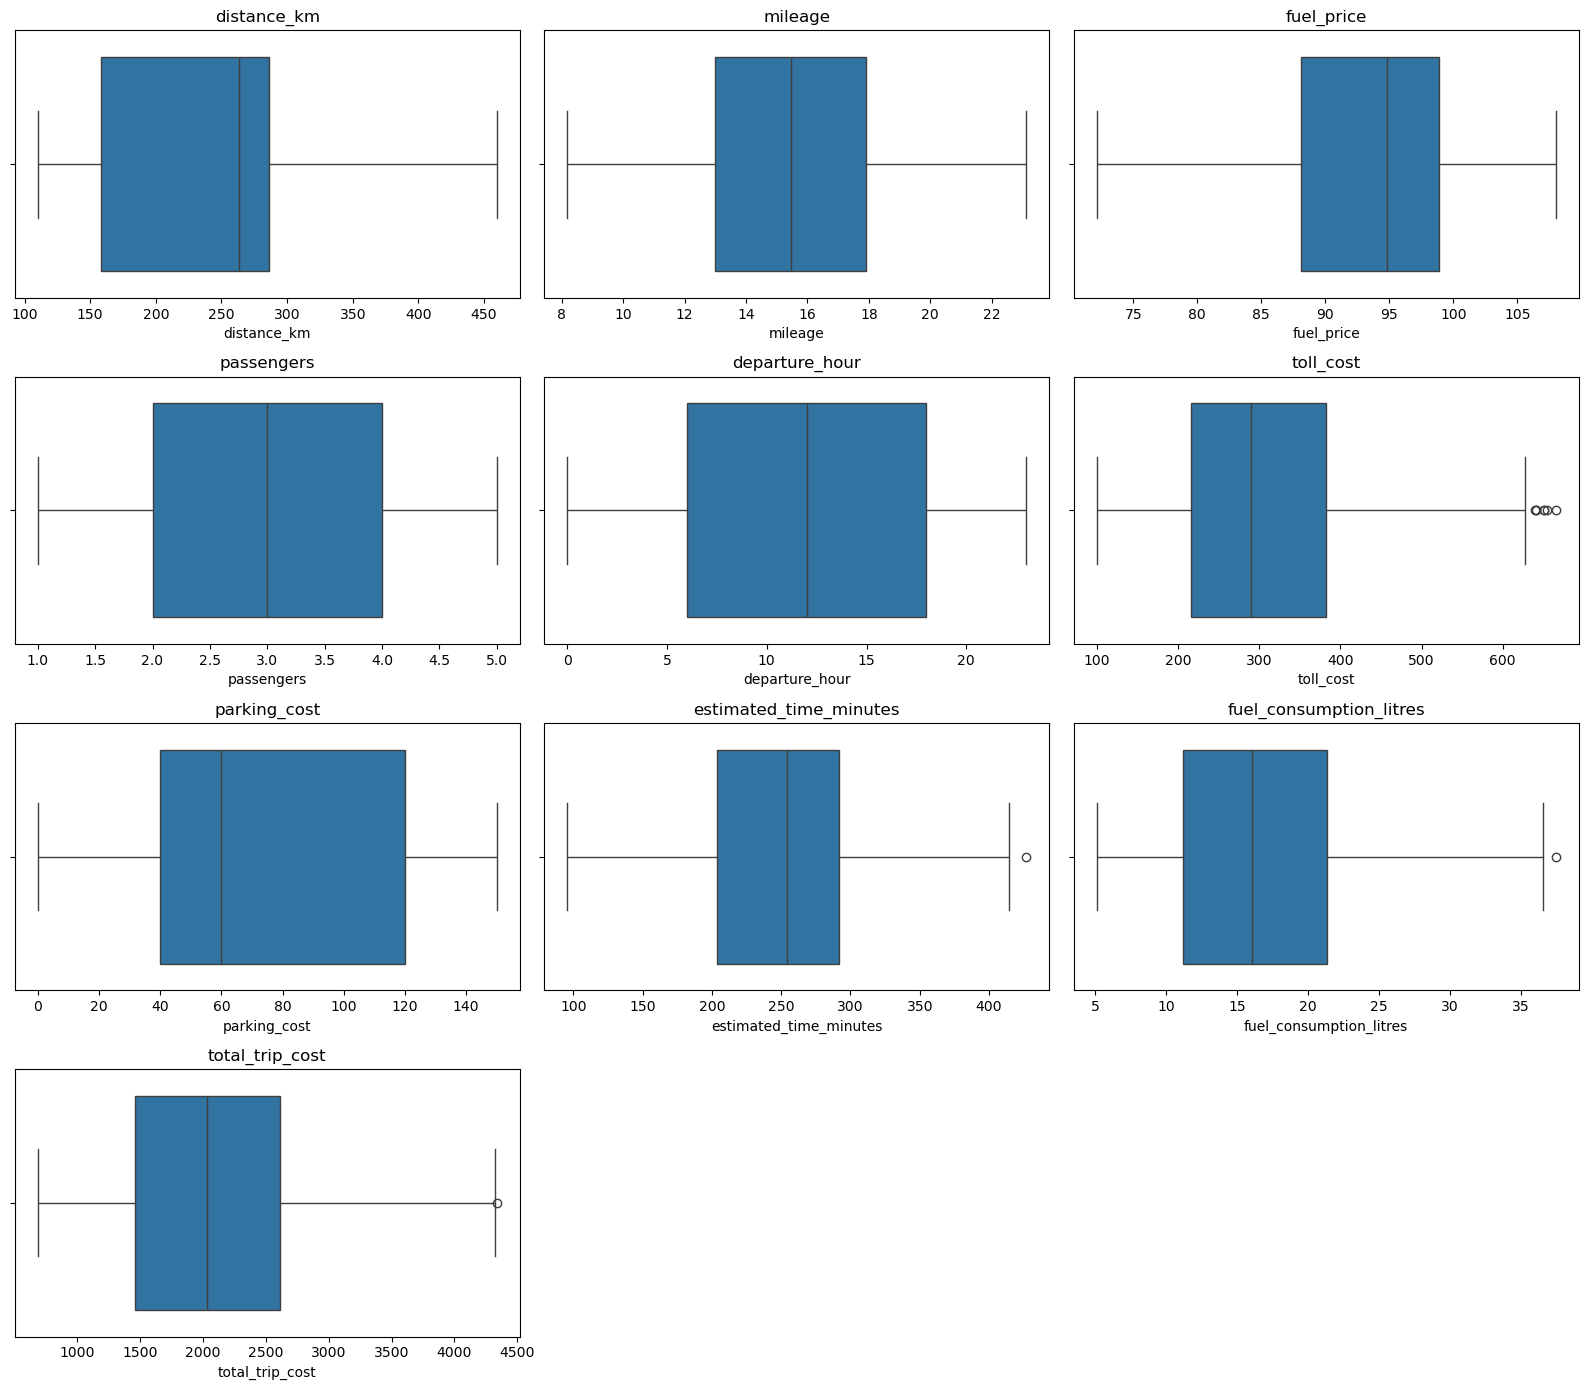

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [14]:
print("Rows before outlier removal:", df.shape[0])

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Rows after outlier removal:", df.shape[0])


Rows before outlier removal: 1140
Rows after outlier removal: 1129


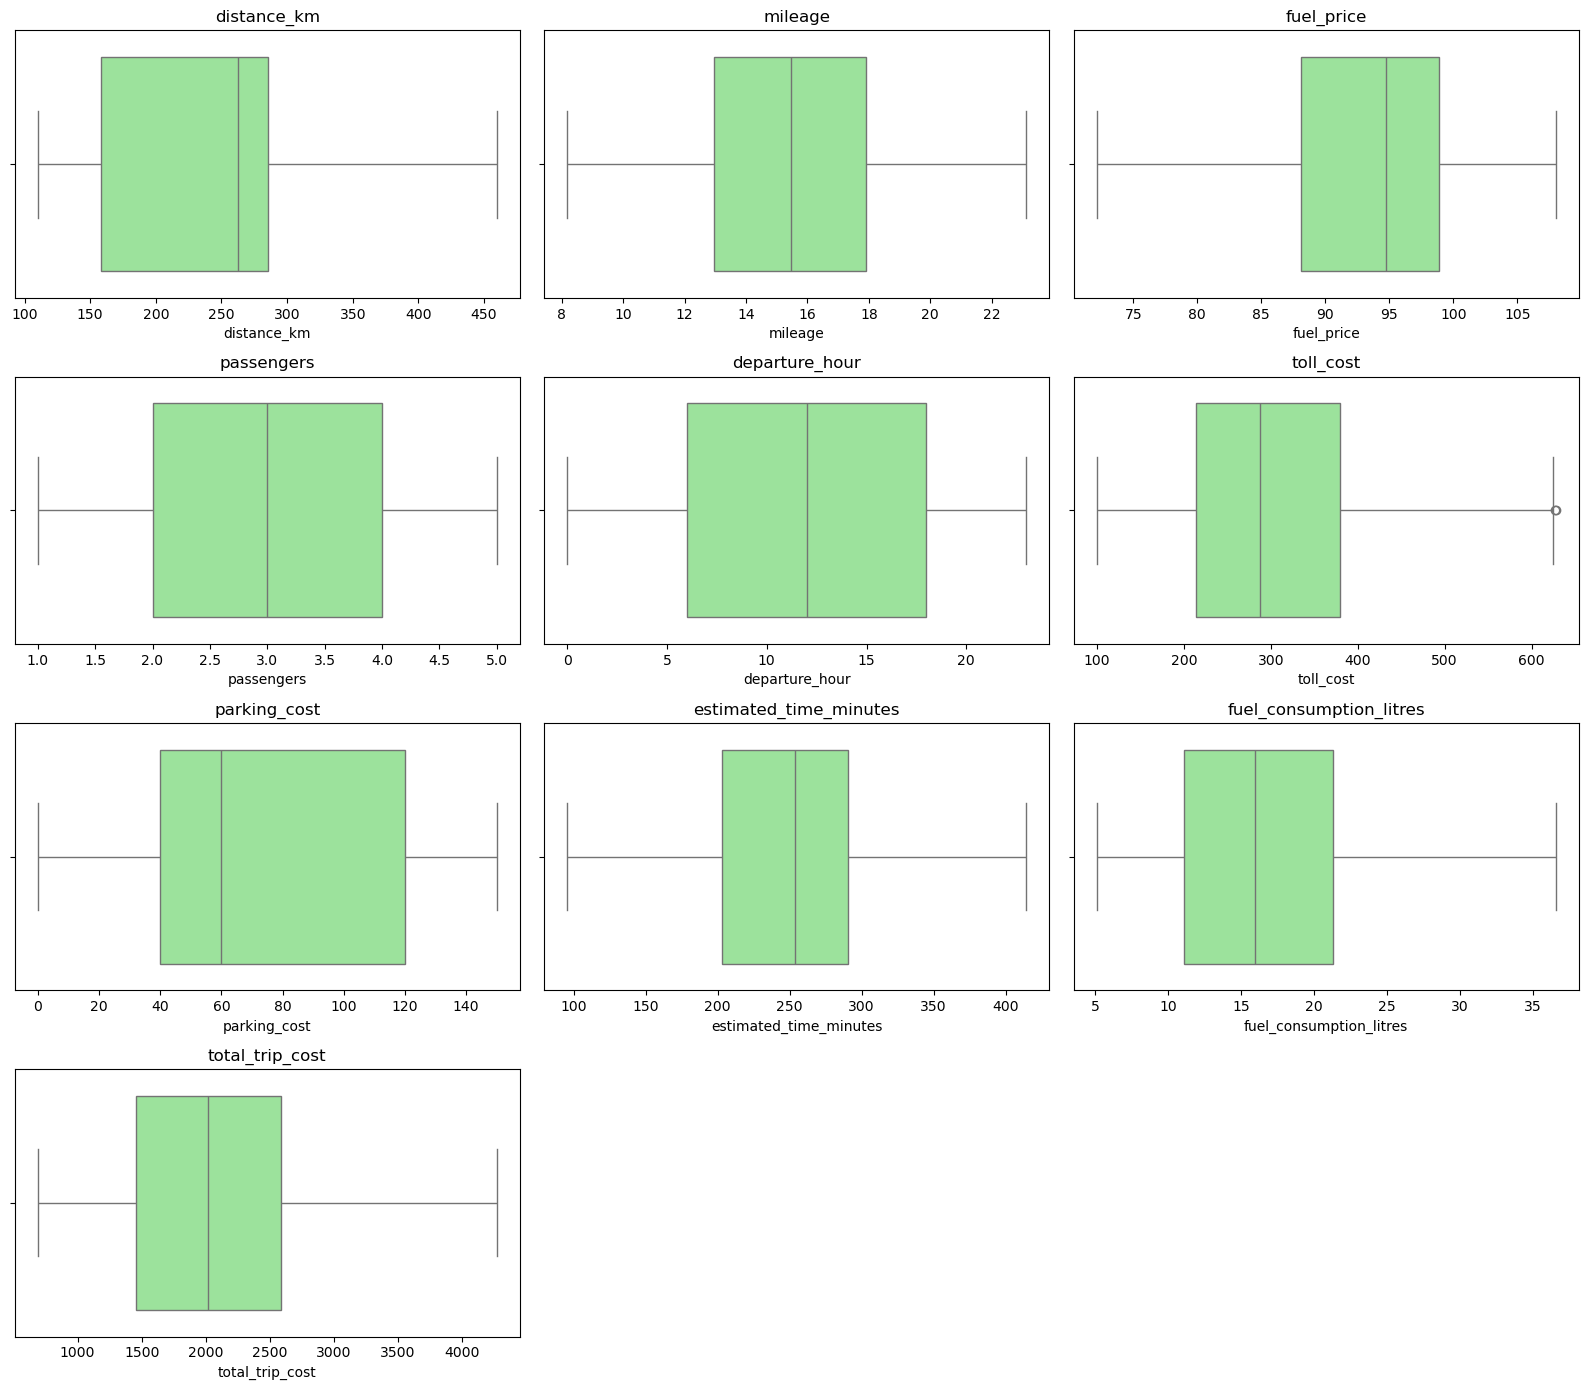

In [15]:
# Boxplots again after outlier removal, to confirm extreme values are gone
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### Step 6: Encode Categorical Columns
Model needs numbers, but columns like `vehicle_type`, `fuel_type`, `traffic_level`, `weather_condition`,
`start_city`, `destination_city` are text. We use **One-Hot Encoding** since these are not ordinal categories.


In [16]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Categorical columns: ['start_city', 'destination_city', 'vehicle_type', 'fuel_type', 'traffic_level', 'weather_condition']
Shape after encoding: (1129, 31)


C:\Users\ABC\AppData\Local\Temp\ipykernel_11728\1919640411.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


,distance_km,mileage,fuel_price,passengers,departure_hour,toll_cost,parking_cost,estimated_time_minutes,fuel_consumption_litres,total_trip_cost,start_city_Bengaluru,start_city_Delhi,start_city_Pune,start_city_Rajkot,start_city_Surat,start_city_Vadodara,destination_city_Jaipur,destination_city_Mumbai,destination_city_Mysuru,destination_city_Surat,destination_city_Udaipur,destination_city_Vadodara,vehicle_type_SUV,vehicle_type_Sedan,fuel_type_Diesel,fuel_type_Petrol,traffic_level_Low,traffic_level_Medium,weather_condition_Cloudy,weather_condition_Fog,weather_condition_Rain
0,148.27,15.67,94.89,5,19,252.47,120.0,173.91,9.677,1393.39,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,True,False,False
1,215.59,21.43,97.64,1,9,217.57,60.0,233.59,10.641,1435.61,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
2,118.93,9.79,83.65,3,19,113.29,40.0,118.00,12.956,1345.60,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False
3,225.28,13.16,88.54,4,5,341.60,80.0,256.44,17.970,2187.79,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False
4,223.63,8.77,95.26,3,18,221.95,80.0,252.12,26.428,2989.54,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False


### Step 7: Scale Numeric Columns
`distance_km` is in hundreds while `passengers` is 1-5 — models get confused by very different scales.
We use **MinMaxScaler** to bring every numeric feature column into the same 0-1 range.


In [17]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = [c for c in df_encoded.columns if c != 'total_trip_cost']
numeric_feature_cols = [c for c in feature_cols
                         if df_encoded[c].dtype in ['float64', 'int64'] and df_encoded[c].nunique() > 2]

scaler = MinMaxScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_feature_cols] = scaler.fit_transform(df_encoded[numeric_feature_cols])

print("Scaled columns:", numeric_feature_cols)
df_scaled.head()


Scaled columns: ['distance_km', 'mileage', 'fuel_price', 'passengers', 'departure_hour', 'toll_cost', 'parking_cost', 'estimated_time_minutes', 'fuel_consumption_litres']


,distance_km,mileage,fuel_price,passengers,departure_hour,toll_cost,parking_cost,estimated_time_minutes,fuel_consumption_litres,total_trip_cost,start_city_Bengaluru,start_city_Delhi,start_city_Pune,start_city_Rajkot,start_city_Surat,start_city_Vadodara,destination_city_Jaipur,destination_city_Mumbai,destination_city_Mysuru,destination_city_Surat,destination_city_Udaipur,destination_city_Vadodara,vehicle_type_SUV,vehicle_type_Sedan,fuel_type_Diesel,fuel_type_Petrol,traffic_level_Low,traffic_level_Medium,weather_condition_Cloudy,weather_condition_Fog,weather_condition_Rain
0,0.109124,0.501339,0.634690,1.00,0.826087,0.289674,0.800000,0.245746,0.145257,1393.39,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,True,False,False
1,0.301737,0.886881,0.711378,0.00,0.391304,0.223598,0.400000,0.433101,0.175924,1435.61,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
2,0.025178,0.107764,0.321249,0.50,0.826087,0.026165,0.266667,0.070227,0.249571,1345.60,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False
3,0.329461,0.333333,0.457613,0.75,0.217391,0.458423,0.533333,0.504835,0.409079,2187.79,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False
4,0.324740,0.039491,0.645008,0.50,0.782609,0.231891,0.533333,0.491273,0.678151,2989.54,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False


### Step 8: Visualize (Numerical & Categorical)

#### A. Numerical Data


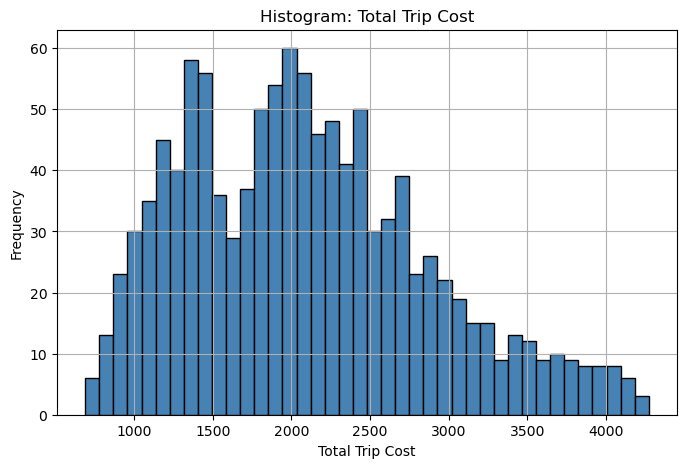

In [18]:
# Histogram - see how total_trip_cost is distributed
df['total_trip_cost'].hist(bins=40, color='steelblue', edgecolor='black')
plt.title('Histogram: Total Trip Cost')
plt.xlabel('Total Trip Cost')
plt.ylabel('Frequency')
plt.show()


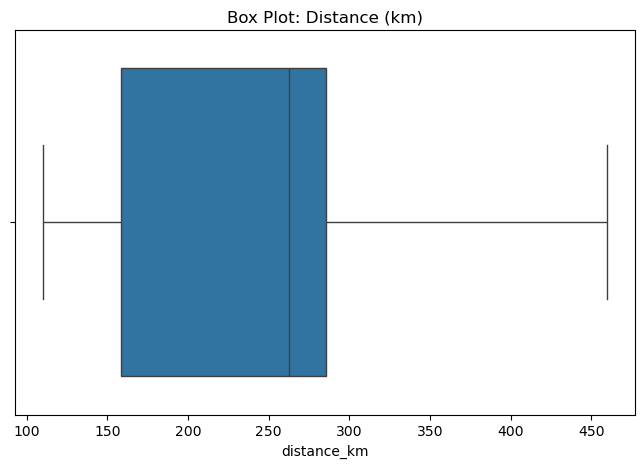

In [19]:
# Box Plot - spot outliers / min / max / median for distance
plt.figure(figsize=(8,5))
sns.boxplot(x=df['distance_km'])
plt.title('Box Plot: Distance (km)')
plt.show()


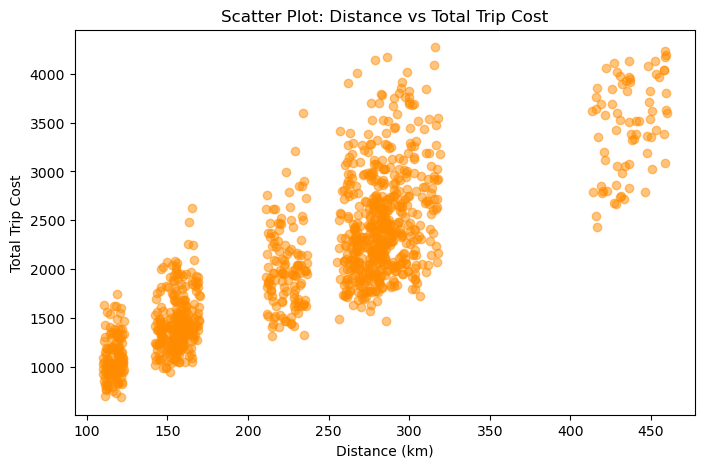

In [20]:
# Scatter Plot - relationship between distance and total trip cost
plt.figure(figsize=(8,5))
plt.scatter(df['distance_km'], df['total_trip_cost'], alpha=0.5, color='darkorange')
plt.title('Scatter Plot: Distance vs Total Trip Cost')
plt.xlabel('Distance (km)')
plt.ylabel('Total Trip Cost')
plt.show()


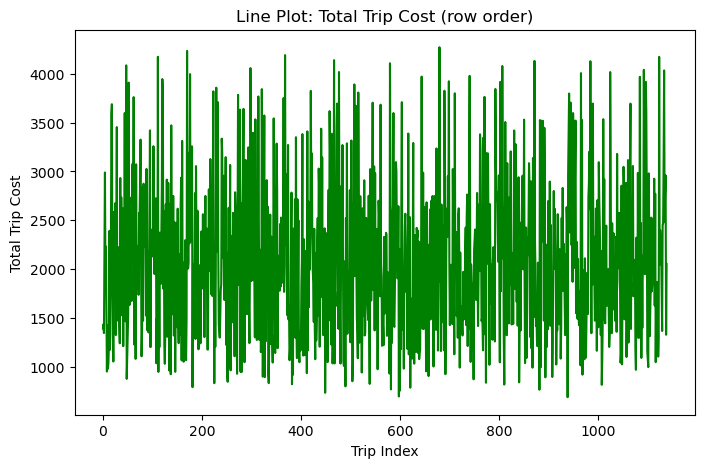

In [21]:
# Line Plot - trend of trip cost over the row order (as a proxy for trend over time)
df['total_trip_cost'].plot(kind='line', color='green')
plt.title('Line Plot: Total Trip Cost (row order)')
plt.xlabel('Trip Index')
plt.ylabel('Total Trip Cost')
plt.show()


#### B. Categorical Data

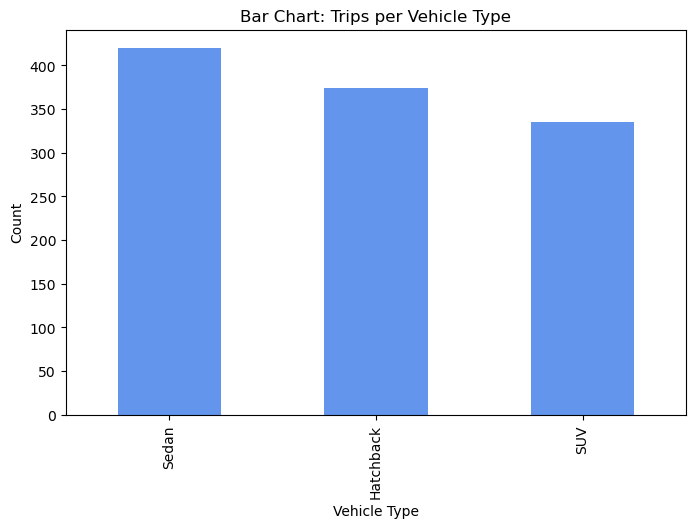

In [22]:
# Bar Chart - compare count of trips per vehicle type
df['vehicle_type'].value_counts().plot(kind='bar', color='cornflowerblue')
plt.title('Bar Chart: Trips per Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.show()


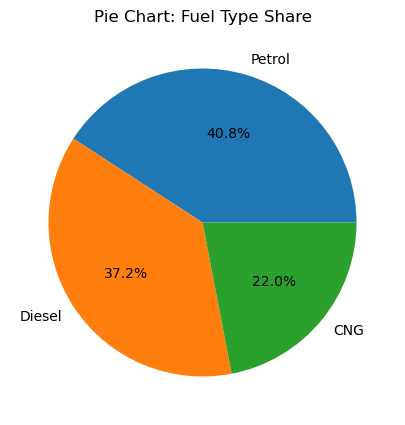

In [23]:
# Pie Chart - proportion of trips per fuel type
df['fuel_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Pie Chart: Fuel Type Share')
plt.ylabel('')
plt.show()


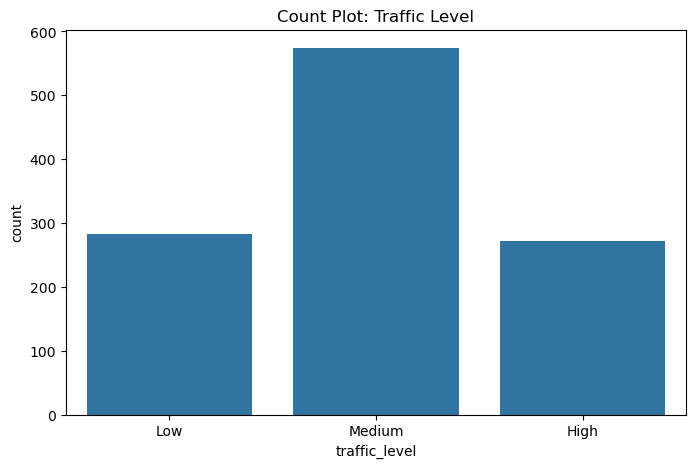

In [24]:
# Count Plot - same as bar chart, seaborn style, for traffic level
plt.figure(figsize=(8,5))
sns.countplot(x='traffic_level', data=df, order=['Low','Medium','High'])
plt.title('Count Plot: Traffic Level')
plt.show()


---

# Week 3: Linear Regression — sklearn `fit()` + Gradient Descent from Scratch

**Task 3 — Machine Learning Lab.** Week 2 (cleaning / preprocessing) is complete above, so this
section starts from the preprocessed table `df_scaled`.

This week has two parts:

| Part | What it does | Tool |
|------|--------------|------|
| **Part A** | Fit a linear model the fast, production way | `sklearn.linear_model.LinearRegression().fit(X, y)` |
| **Part B** | Find the *same* parameters by hand, so we can see what `fit()` is doing underneath | NumPy only — our own loss, gradients and update rule |

Then we **compare** the two sets of parameters and explain any difference.

Because our dataset has many useful columns, we apply **Multiple Linear Regression**:

$$\hat{Y} = w_1X_1 + w_2X_2 + \dots + w_kX_k + c$$

The `total_trip_cost` target is **continuous**, so this is a regression problem — no substitute
dataset is needed.

## 3.1 Setup — Continue From the Week 2 Preprocessed Data

`df_scaled` (produced in Week 2, Step 7) is the cleaned → de-duplicated → outlier-trimmed →
one-hot-encoded → MinMax-scaled table. The target column `total_trip_cost` was deliberately
**left unscaled** so the learned coefficients stay in rupees and are easy to read.

In [25]:
# ---------- Week 3 imports (everything else is already imported in Week 1) ----------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("df_scaled shape :", df_scaled.shape)
print("Target column   : total_trip_cost  (continuous -> regression problem)")
print("Rows available  :", len(df_scaled))
df_scaled.head(3)

df_scaled shape : (1129, 31)
Target column   : total_trip_cost  (continuous -> regression problem)
Rows available  : 1129


,distance_km,mileage,fuel_price,passengers,departure_hour,toll_cost,parking_cost,estimated_time_minutes,fuel_consumption_litres,total_trip_cost,start_city_Bengaluru,start_city_Delhi,start_city_Pune,start_city_Rajkot,start_city_Surat,start_city_Vadodara,destination_city_Jaipur,destination_city_Mumbai,destination_city_Mysuru,destination_city_Surat,destination_city_Udaipur,destination_city_Vadodara,vehicle_type_SUV,vehicle_type_Sedan,fuel_type_Diesel,fuel_type_Petrol,traffic_level_Low,traffic_level_Medium,weather_condition_Cloudy,weather_condition_Fog,weather_condition_Rain
0,0.109124,0.501339,0.634690,1.0,0.826087,0.289674,0.800000,0.245746,0.145257,1393.39,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,True,False,False
1,0.301737,0.886881,0.711378,0.0,0.391304,0.223598,0.400000,0.433101,0.175924,1435.61,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
2,0.025178,0.107764,0.321249,0.5,0.826087,0.026165,0.266667,0.070227,0.249571,1345.60,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False


## 3.2 Select the Target (Y) and the Feature Columns (X)

First look at which numeric columns actually move with the target.

fuel_consumption_litres    0.960583
distance_km                0.831526
estimated_time_minutes     0.728170
toll_cost                  0.670144
fuel_price                 0.145048
parking_cost               0.097013
departure_hour            -0.026141
passengers                -0.046777
mileage                   -0.380176
Name: total_trip_cost, dtype: float64


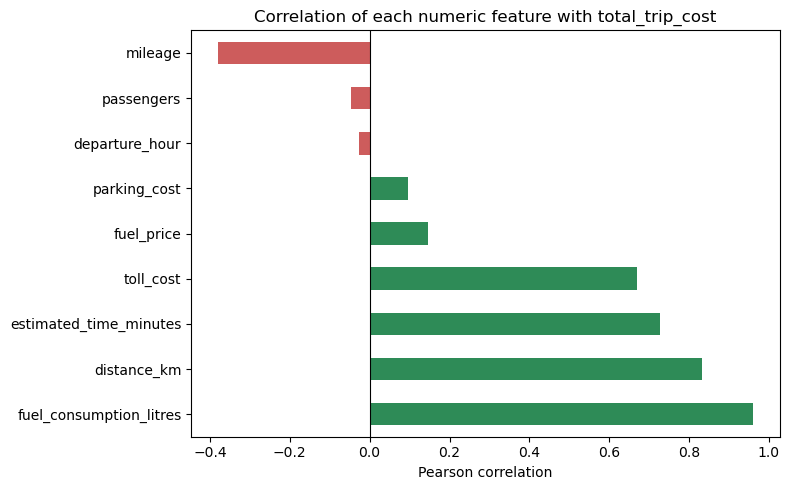

In [26]:
# Correlation of every numeric column with the target
corr_with_target = (df[numeric_cols]
                    .corr()['total_trip_cost']
                    .drop('total_trip_cost')
                    .sort_values(ascending=False))
print(corr_with_target)

plt.figure(figsize=(8, 5))
bar_colors = ['seagreen' if v > 0 else 'indianred' for v in corr_with_target]
corr_with_target.plot(kind='barh', color=bar_colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of each numeric feature with total_trip_cost')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

### Which columns we keep, and why

**Target (Y): `total_trip_cost`** — continuous rupee value, exactly what we want to predict.

**Features (X):** six numeric columns that are the real cost drivers of a road trip:

| Feature | Why it is included |
|---------|--------------------|
| `distance_km` | longer trip → more fuel burnt (corr **+0.83**) |
| `mileage` | a more efficient vehicle burns less fuel (corr **−0.38**, the only strong negative) |
| `fuel_price` | price per litre on the day of travel |
| `toll_cost` | a direct additive component of the bill (corr **+0.67**) |
| `parking_cost` | another direct additive component |
| `fuel_consumption_litres` | litres actually burnt — the single strongest driver (corr **+0.96**) |

**Columns we deliberately leave out:**

* `passengers` and `departure_hour` — correlation with the target is ≈ 0 (−0.05 and −0.03); they add
  noise without adding signal.
* `estimated_time_minutes` — almost a copy of `distance_km`, so it only adds multicollinearity.
* **All the one-hot columns** (`start_city_*`, `destination_city_*`, `vehicle_type_*`, …) — in this
  dataset every route is a fixed pair, so `start_city_Delhi` and `destination_city_Jaipur` are
  **identical columns**. That makes the design matrix *rank-deficient*: infinitely many weight
  combinations give the exact same predictions. sklearn silently picks one via its pseudo-inverse,
  gradient descent would converge on a different one, and the Part A vs Part B comparison would look
  broken even though both models are correct. Dropping them keeps the comparison honest.

This is still a valid **multiple** linear regression — the task asks for "one or more feature columns".

In [27]:
TARGET   = 'total_trip_cost'
FEATURES = ['distance_km', 'mileage', 'fuel_price',
            'toll_cost', 'parking_cost', 'fuel_consumption_litres']

X = df_scaled[FEATURES].values.astype(float)   # shape (n_samples, n_features)
y = df_scaled[TARGET].values.astype(float)     # shape (n_samples,)

print("Target   (Y):", TARGET)
print("Features (X):", FEATURES)
print()
print("X shape :", X.shape)
print("y shape :", y.shape)
print()
print("X range : {:.3f} .. {:.3f}   (MinMax scaled in Week 2)".format(X.min(), X.max()))
print("y range : {:.2f} .. {:.2f}   (rupees, unscaled)".format(y.min(), y.max()))

Target   (Y): total_trip_cost
Features (X): ['distance_km', 'mileage', 'fuel_price', 'toll_cost', 'parking_cost', 'fuel_consumption_litres']

X shape : (1129, 6)
y shape : (1129,)

X range : 0.000 .. 1.000   (MinMax scaled in Week 2)
y range : 688.79 .. 4271.82   (rupees, unscaled)


---

# Part A — Fit the Model Using sklearn's `LinearRegression()`

This is the fast, library way: sklearn solves the normal equations internally in one shot.

In [28]:
# ---------- PART A ----------
lin_model = LinearRegression()
lin_model.fit(X, y)          # <-- the fit() step the task requires

print("Coefficients (one weight per feature):")
print(lin_model.coef_)
print()
print("Intercept (c):", lin_model.intercept_)

Coefficients (one weight per feature):
[ 225.0381764   -79.41024483  636.32323769  547.34815603  165.48754941
 2938.49410366]

Intercept (c): 301.32345023610196


In [29]:
# Same numbers, presented readably
sk_coefs = pd.DataFrame({
    'feature'       : FEATURES,
    'sklearn_weight': lin_model.coef_
})
sk_intercept = lin_model.intercept_

display(sk_coefs.round(4))
print(f"Intercept (bias c) = {sk_intercept:.4f}")

terms = "  +  ".join(f"({w:.2f} x {f})" for f, w in zip(FEATURES, lin_model.coef_))
print("\nLearned equation:")
print(f"total_trip_cost  =  {terms}  +  {sk_intercept:.2f}")

,feature,sklearn_weight
0,distance_km,225.0382
1,mileage,-79.4102
2,fuel_price,636.3232
3,toll_cost,547.3482
4,parking_cost,165.4875
5,fuel_consumption_litres,2938.4941


Intercept (bias c) = 301.3235

Learned equation:
total_trip_cost  =  (225.04 x distance_km)  +  (-79.41 x mileage)  +  (636.32 x fuel_price)  +  (547.35 x toll_cost)  +  (165.49 x parking_cost)  +  (2938.49 x fuel_consumption_litres)  +  301.32


**Reading the coefficients.** Every feature was MinMax-scaled to `0..1` in Week 2, so a weight is
"how many rupees the cost changes when that feature goes from its minimum to its maximum".
`fuel_consumption_litres` has by far the largest weight — burning fuel is the dominant cost — while
`mileage` is negative, which matches intuition: a more efficient vehicle costs less to run.

R2   : 0.992841
MSE  : 4284.6703
RMSE : 65.4574  rupees
MAE  : 48.2964  rupees


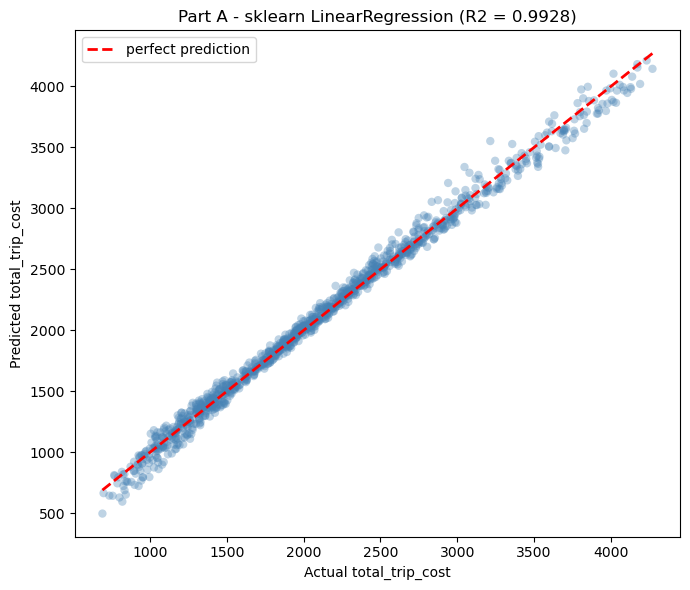

In [30]:
# How good is this fit?
y_pred_sklearn = lin_model.predict(X)

r2_sk   = r2_score(y, y_pred_sklearn)
mse_sk  = mean_squared_error(y, y_pred_sklearn)
rmse_sk = np.sqrt(mse_sk)
mae_sk  = mean_absolute_error(y, y_pred_sklearn)

print(f"R2   : {r2_sk:.6f}")
print(f"MSE  : {mse_sk:.4f}")
print(f"RMSE : {rmse_sk:.4f}  rupees")
print(f"MAE  : {mae_sk:.4f}  rupees")

plt.figure(figsize=(7, 6))
plt.scatter(y, y_pred_sklearn, alpha=0.35, color='steelblue', edgecolor='none')
lims = [y.min(), y.max()]
plt.plot(lims, lims, 'r--', linewidth=2, label='perfect prediction')
plt.xlabel('Actual total_trip_cost')
plt.ylabel('Predicted total_trip_cost')
plt.title(f'Part A - sklearn LinearRegression (R2 = {r2_sk:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

---

# Part B (Warm-up) — Simple Linear Regression With One Feature

Before doing all six features at once, here is the **exact `m` and `c` case from the task sheet's
iPhone example**, but on our own data:

$$Y = m \cdot X + c \qquad\text{where}\qquad X = \texttt{distance\_km},\; Y = \texttt{total\_trip\_cost}$$

This makes the mechanics easy to see, and the multi-feature version in the next section is just the
same three lines written with vectors.

In [31]:
# sklearn's answer for the single-feature model, so we have something to aim at
x_simple = df_scaled['distance_km'].values.astype(float)   # X  (scaled 0..1)
y_simple = y                                               # Y  (rupees)

simple_model = LinearRegression().fit(x_simple.reshape(-1, 1), y_simple)
sk_m = simple_model.coef_[0]
sk_c = simple_model.intercept_

print(f"sklearn  ->  m (slope) = {sk_m:.4f}     c (intercept) = {sk_c:.4f}")
print(f"R2 using distance alone: {simple_model.score(x_simple.reshape(-1, 1), y_simple):.4f}")

sklearn  ->  m (slope) = 2695.2028     c (intercept) = 1109.3183
R2 using distance alone: 0.6914


### The three steps of gradient descent

**1. Loss function** — Mean Squared Error, how wrong the current line is:

$$L(m, c) = \frac{1}{n}\sum_{i=1}^{n}\bigl(Y_i - (m X_i + c)\bigr)^2$$

**2. Gradients** — which direction *increases* the loss:

$$\frac{\partial L}{\partial m} = \frac{2}{n}\sum X_i \cdot \text{error}_i
\qquad
\frac{\partial L}{\partial c} = \frac{2}{n}\sum \text{error}_i
\qquad (\text{error} = \hat{Y} - Y)$$

**3. Update rule** — step in the *opposite* direction (that is the "descent"):

$$m \leftarrow m - lr \cdot \frac{\partial L}{\partial m}
\qquad
c \leftarrow c - lr \cdot \frac{\partial L}{\partial c}$$

In [32]:
def gradient_descent_simple(X, Y, lr=0.1, epochs=20000, tol=1e-8, print_every=2000):
    '''Fit Y = m*X + c by gradient descent. Pure NumPy - no sklearn.'''
    m, c = 0.0, 0.0          # 1. initial guess
    n = len(X)
    loss_history = []
    stopped_at = epochs

    for i in range(epochs):
        Y_pred = m * X + c                       # current prediction
        error  = Y_pred - Y                      # predicted - actual
        loss   = (1 / n) * np.sum(error ** 2)    # MSE loss
        loss_history.append(loss)

        dm = (2 / n) * np.sum(error * X)         # gradient w.r.t. m
        dc = (2 / n) * np.sum(error)             # gradient w.r.t. c

        m = m - lr * dm                          # update m
        c = c - lr * dc                          # update c

        if i % print_every == 0:
            print(f"epoch {i:>6}:  loss = {loss:12.4f}   m = {m:10.4f}   c = {c:10.4f}")

        # convergence check: has the loss stopped changing?
        if i > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
            stopped_at = i + 1
            print(f"epoch {i:>6}:  loss = {loss:12.4f}   m = {m:10.4f}   c = {c:10.4f}   <-- converged")
            break

    return m, c, loss_history, stopped_at


gd_m, gd_c, simple_loss, simple_stop = gradient_descent_simple(
    x_simple, y_simple, lr=0.1, epochs=20000
)

print()
print(f"Final parameters ->  m: {gd_m:.4f}   c: {gd_c:.4f}")
print(f"Converged after {simple_stop} epochs (budget was 20000)")

epoch      0:  loss = 4989244.1242   m =   184.0375   c =   419.0823
epoch   1338:  loss =  184674.2309   m =  2695.1999   c =  1109.3194   <-- converged

Final parameters ->  m: 2695.1999   c: 1109.3194
Converged after 1339 epochs (budget was 20000)


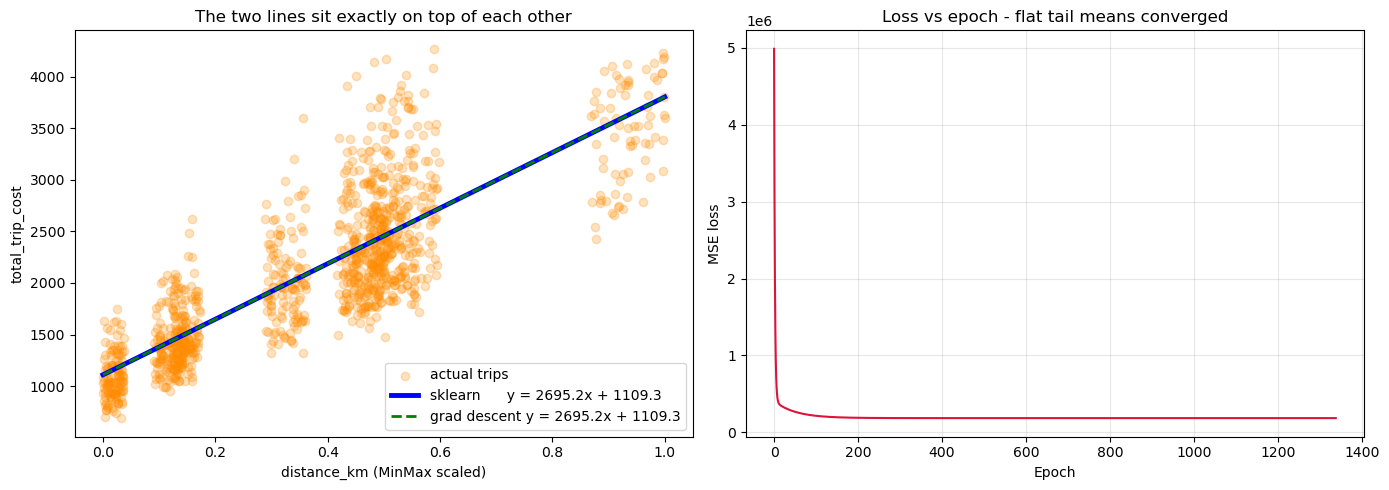

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: the two fitted lines on top of the data
ax[0].scatter(x_simple, y_simple, alpha=0.25, color='darkorange', label='actual trips')
xs = np.linspace(0, 1, 100)
ax[0].plot(xs, sk_m * xs + sk_c, 'b-',  linewidth=3.5, label=f'sklearn      y = {sk_m:.1f}x + {sk_c:.1f}')
ax[0].plot(xs, gd_m * xs + gd_c, 'g--', linewidth=2.0, label=f'grad descent y = {gd_m:.1f}x + {gd_c:.1f}')
ax[0].set_xlabel('distance_km (MinMax scaled)')
ax[0].set_ylabel('total_trip_cost')
ax[0].set_title('The two lines sit exactly on top of each other')
ax[0].legend()

# Right: the loss curve
ax[1].plot(simple_loss, color='crimson')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('MSE loss')
ax[1].set_title('Loss vs epoch - flat tail means converged')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Do the simple-model parameters match?
simple_cmp = pd.DataFrame({
    'parameter'       : ['m  (slope)', 'c  (intercept)'],
    'sklearn'         : [sk_m, sk_c],
    'gradient_descent': [gd_m, gd_c],
})
simple_cmp['abs_diff'] = (simple_cmp['sklearn'] - simple_cmp['gradient_descent']).abs()
simple_cmp['pct_diff'] = simple_cmp['abs_diff'] / simple_cmp['sklearn'].abs() * 100
simple_cmp.round(6)

,parameter,sklearn,gradient_descent,abs_diff,pct_diff
0,m (slope),2695.202781,2695.199903,0.002878,0.000107
1,c (intercept),1109.318269,1109.319377,0.001108,0.000100


---

# Part B — Gradient Descent From Scratch for **All Six Features**

Extending `m, c` to `w, b`: one weight per feature plus a single bias term. The loss keeps the same
form, and each weight gets its own gradient:

$$\hat{Y} = X w + b
\qquad
L(w, b) = \frac{1}{n}\sum_{i=1}^{n}\bigl(\hat{Y_i} - Y_i\bigr)^2$$

$$\frac{\partial L}{\partial w_j} = \frac{2}{n}\sum_{i} X_{ij}\cdot\text{error}_i
\qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i}\text{error}_i$$

$$w_j \leftarrow w_j - lr \cdot \frac{\partial L}{\partial w_j}
\qquad
b \leftarrow b - lr \cdot \frac{\partial L}{\partial b}$$

Rather than one Python variable per feature, all six gradients are computed in a single matrix
operation `X.T @ error` — this is the vectorised NumPy form the task sheet mentions in section 5.1.

In [35]:
def gradient_descent(X, Y, lr=0.2, epochs=50000, tol=1e-8, print_every=2000):
    '''
    Multiple linear regression by gradient descent - no sklearn.

        Y_hat = X @ w + b       w = one weight per feature, b = bias / intercept

    Returns (w, b, loss_history, epochs_actually_used).
    '''
    n, k = X.shape
    w = np.zeros(k)          # 1. initial guess: all weights zero
    b = 0.0                  #    and bias zero
    loss_history = []
    stopped_at = epochs

    for i in range(epochs):
        Y_pred = X.dot(w) + b                    # current prediction
        error  = Y_pred - Y                      # predicted - actual
        loss   = (1 / n) * np.sum(error ** 2)    # MSE loss
        loss_history.append(loss)

        dw = (2 / n) * X.T.dot(error)            # gradient w.r.t. every weight (vector)
        db = (2 / n) * np.sum(error)             # gradient w.r.t. bias (scalar)

        w = w - lr * dw                          # update all weights at once
        b = b - lr * db                          # update bias

        if i % print_every == 0:
            print(f"epoch {i:>6}:  loss = {loss:13.4f}   b = {b:9.4f}   "
                  f"w = [{', '.join(f'{v:8.2f}' for v in w)}]")

        # convergence check from the task sheet: stop when the loss goes flat
        if i > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
            stopped_at = i + 1
            print(f"epoch {i:>6}:  loss = {loss:13.4f}   b = {b:9.4f}   "
                  f"w = [{', '.join(f'{v:8.2f}' for v in w)}]   <-- converged")
            break

    return w, b, loss_history, stopped_at

In [36]:
LR     = 0.2      # learning rate
EPOCHS = 50000    # maximum number of passes (early stopping usually triggers first)

gd_w, gd_b, loss_history, stopped_at = gradient_descent(X, y, lr=LR, epochs=EPOCHS, print_every=2000)

print()
print("=" * 68)
print("FINAL LEARNED PARAMETERS  (gradient descent from scratch)")
print("=" * 68)
for f, wi in zip(FEATURES, gd_w):
    print(f"  w[{f:<25}] = {wi:13.6f}")
print(f"  {'b  (bias / intercept)':<28} = {gd_b:13.6f}")
print()
print(f"Final MSE loss : {loss_history[-1]:.6f}")
print(f"Epochs used    : {stopped_at} of {EPOCHS}  (stopped once the loss changed by < 1e-8)")

epoch      0:  loss =  4989244.1242   b =  838.1646   w = [  368.07,   382.20,   499.48,   364.17,   393.27,   376.62]
epoch   2000:  loss =     4614.7062   b =  413.0932   w = [  466.10,  -244.11,   632.85,   526.96,   163.82,  2645.89]
epoch   4000:  loss =     4303.3776   b =  327.9337   w = [  282.43,  -118.62,   635.50,   542.49,   165.09,  2868.83]
epoch   6000:  loss =     4285.7307   b =  307.6588   w = [  238.70,   -88.75,   636.13,   546.19,   165.39,  2921.91]
epoch   8000:  loss =     4284.7304   b =  302.8318   w = [  228.29,   -81.63,   636.28,   547.07,   165.47,  2934.55]
epoch  10000:  loss =     4284.6737   b =  301.6826   w = [  225.81,   -79.94,   636.31,   547.28,   165.48,  2937.55]
epoch  12000:  loss =     4284.6705   b =  301.4089   w = [  225.22,   -79.54,   636.32,   547.33,   165.49,  2938.27]
epoch  14000:  loss =     4284.6703   b =  301.3438   w = [  225.08,   -79.44,   636.32,   547.34,   165.49,  2938.44]
epoch  14316:  loss =     4284.6703   b =  301.3

### The loss curve

The task sheet's practical rule: *plot loss vs. epoch and stop when the curve goes flat*. Three views
of the same run — the raw curve, a zoom on the steep first phase, and a log-scale version that shows
the long flat tail where the last few decimal places are being squeezed out.

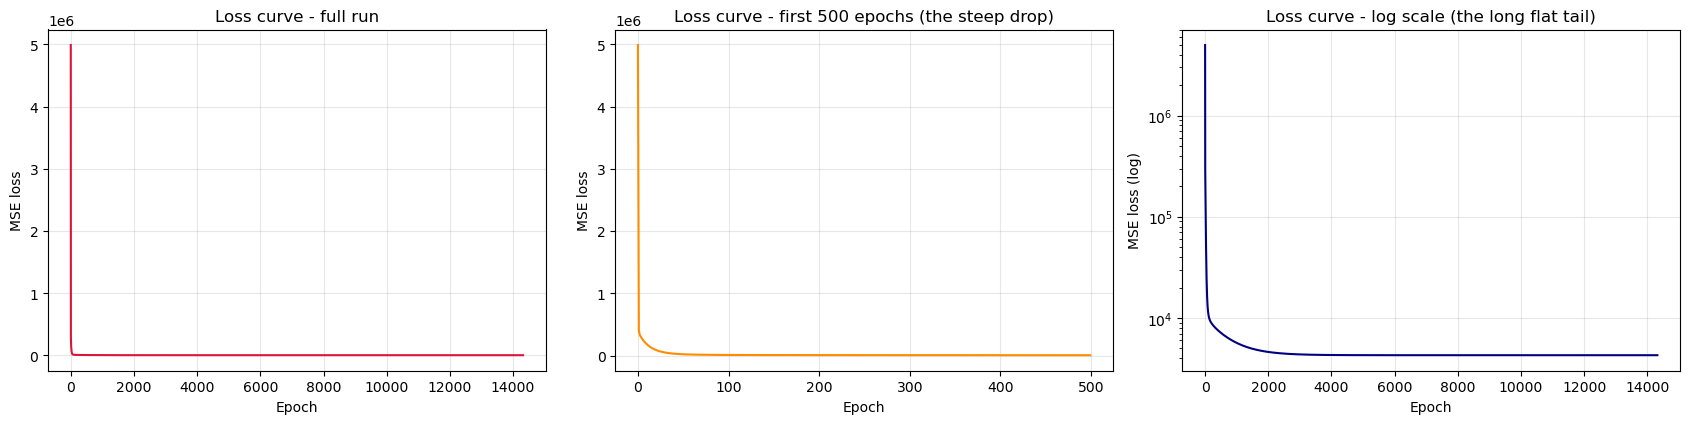

Loss at selected epochs:
   epoch      0 :  4989244.1242
   epoch     10 :   180559.5941
   epoch    100 :    11087.4571
   epoch    500 :     7131.7866
   epoch   1000 :     5670.9180
   epoch   5000 :     4289.1241
   epoch  10000 :     4284.6737
   epoch  14316 :     4284.6703   <-- final


In [37]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

ax[0].plot(loss_history, color='crimson')
ax[0].set_title('Loss curve - full run')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE loss'); ax[0].grid(alpha=0.3)

ax[1].plot(loss_history[:500], color='darkorange')
ax[1].set_title('Loss curve - first 500 epochs (the steep drop)')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('MSE loss'); ax[1].grid(alpha=0.3)

ax[2].plot(loss_history, color='navy')
ax[2].set_yscale('log')
ax[2].set_title('Loss curve - log scale (the long flat tail)')
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('MSE loss (log)'); ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Loss at selected epochs:")
for ep in [0, 10, 100, 500, 1000, 5000, 10000]:
    if ep < len(loss_history):
        print(f"   epoch {ep:>6} : {loss_history[ep]:13.4f}")
print(f"   epoch {len(loss_history) - 1:>6} : {loss_history[-1]:13.4f}   <-- final")

---

# Compare — Do the Two Sets of Parameters Match?

In [38]:
comparison = pd.DataFrame({
    'parameter'       : FEATURES + ['INTERCEPT (c / b)'],
    'sklearn'         : list(lin_model.coef_) + [lin_model.intercept_],
    'gradient_descent': list(gd_w)            + [gd_b],
})
comparison['abs_diff'] = (comparison['sklearn'] - comparison['gradient_descent']).abs()
comparison['pct_diff'] = comparison['abs_diff'] / comparison['sklearn'].abs() * 100

display(comparison.round(6))

print(f"Largest absolute difference   : {comparison['abs_diff'].max():.6f}")
print(f"Largest percentage difference : {comparison['pct_diff'].max():.6f} %")

,parameter,sklearn,gradient_descent,abs_diff,pct_diff
0,distance_km,225.038176,225.073171,0.034994,0.015550
1,mileage,-79.410245,-79.434153,0.023908,0.030107
2,fuel_price,636.323238,636.322734,0.000504,0.000079
3,toll_cost,547.348156,547.345196,0.002960,0.000541
4,parking_cost,165.487549,165.487307,0.000242,0.000146
5,fuel_consumption_litres,2938.494104,2938.451627,0.042477,0.001446
6,INTERCEPT (c / b),301.323450,301.339676,0.016225,0.005385


Largest absolute difference   : 0.042477
Largest percentage difference : 0.030107 %


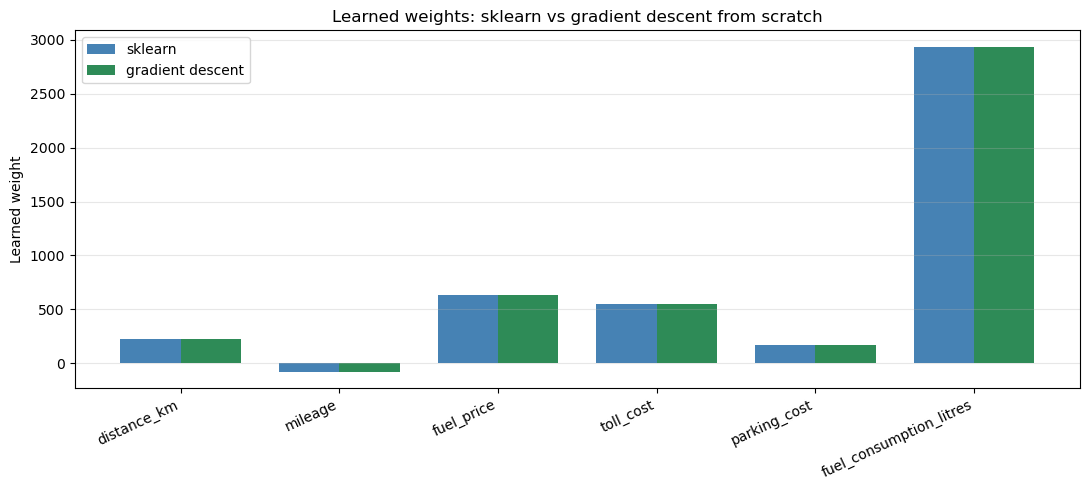

In [39]:
idx   = np.arange(len(FEATURES))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(idx - width / 2, lin_model.coef_, width, label='sklearn',          color='steelblue')
plt.bar(idx + width / 2, gd_w,            width, label='gradient descent', color='seagreen')
plt.xticks(idx, FEATURES, rotation=25, ha='right')
plt.ylabel('Learned weight')
plt.title('Learned weights: sklearn vs gradient descent from scratch')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Do the two models also make the same predictions?
y_pred_gd = X.dot(gd_w) + gd_b

print(f"{'metric':<10}{'sklearn':>16}{'gradient descent':>20}")
print("-" * 46)
print(f"{'R2':<10}{r2_score(y, y_pred_sklearn):>16.6f}{r2_score(y, y_pred_gd):>20.6f}")
print(f"{'RMSE':<10}{np.sqrt(mean_squared_error(y, y_pred_sklearn)):>16.4f}"
      f"{np.sqrt(mean_squared_error(y, y_pred_gd)):>20.4f}")
print(f"{'MAE':<10}{mean_absolute_error(y, y_pred_sklearn):>16.4f}"
      f"{mean_absolute_error(y, y_pred_gd):>20.4f}")

print(f"\nLargest gap between the two models' predictions: "
      f"{np.max(np.abs(y_pred_sklearn - y_pred_gd)):.6f} rupees")

pd.DataFrame({
    'actual'      : y[:10],
    'sklearn_pred': y_pred_sklearn[:10],
    'gd_pred'     : y_pred_gd[:10],
}).round(3)

metric             sklearn    gradient descent
----------------------------------------------
R2                0.992841            0.992841
RMSE               65.4574             65.4574
MAE                48.2964             48.2965

Largest gap between the two models' predictions: 0.011354 rupees


,actual,sklearn_pred,gd_pred
0,1393.39,1407.716,1407.717
1,1435.61,1456.997,1456.994
2,1345.60,1294.663,1294.667
3,2187.79,2181.439,2181.440
4,2989.54,2989.628,2989.625
5,1951.90,1994.585,1994.584
6,2231.10,2200.432,2200.434
7,1602.66,1669.452,1669.457
8,951.50,793.034,793.035
9,1425.83,1522.251,1522.249


---

## Where a Difference *Would* Come From — Learning Rate and Epochs

The two parameter sets above agree. That is not automatic: it happens because the learning rate and
epoch count were chosen well. The next two experiments show what goes wrong otherwise — this is the
evidence behind the explanation note at the end.

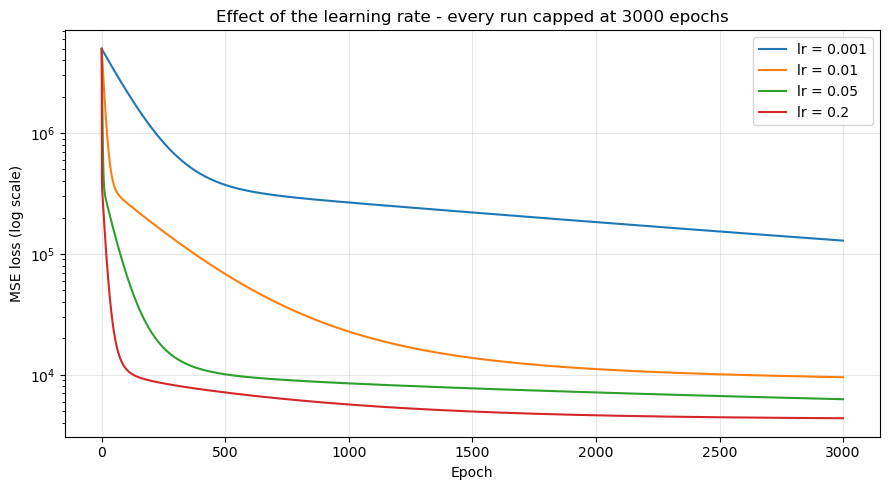

After 3000 epochs, distance from sklearn's answer:


,learning_rate,final_loss,max_weight_error,intercept_error
0,0.001,128922.0289,2024.6947,530.2085
1,0.010,9535.8956,1168.0479,418.5636
2,0.050,6270.7747,719.3495,274.5981
3,0.200,4363.3584,142.8746,54.5755


In [41]:
def run_gd_quiet(X, Y, lr, epochs):
    '''Same algorithm as gradient_descent(), but silent and with no early stopping.'''
    n, k = X.shape
    w = np.zeros(k)
    b = 0.0
    hist = []
    for _ in range(epochs):
        error = X.dot(w) + b - Y
        hist.append((1 / n) * np.sum(error ** 2))
        w = w - lr * (2 / n) * X.T.dot(error)
        b = b - lr * (2 / n) * np.sum(error)
    return w, b, hist


EPOCH_BUDGET = 3000
rates = [0.001, 0.01, 0.05, 0.2]
rows  = []

plt.figure(figsize=(9, 5))
for lr_val in rates:
    w_, b_, h_ = run_gd_quiet(X, y, lr_val, EPOCH_BUDGET)
    plt.plot(h_, label=f'lr = {lr_val}')
    rows.append({
        'learning_rate'    : lr_val,
        'final_loss'       : h_[-1],
        'max_weight_error' : np.max(np.abs(w_ - lin_model.coef_)),
        'intercept_error'  : abs(b_ - lin_model.intercept_),
    })

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE loss (log scale)')
plt.title(f'Effect of the learning rate - every run capped at {EPOCH_BUDGET} epochs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"After {EPOCH_BUDGET} epochs, distance from sklearn's answer:")
display(pd.DataFrame(rows).round(4))

**Reading this chart.** With `lr = 0.001` the loss is still falling steeply at epoch 3000 — the run
was stopped long before it arrived, so its weights are still about **2025 rupees** away from
sklearn's. Raising the learning rate steadily closes that gap for the *same* epoch budget:
`0.001 → 2025 off`, `0.01 → 1168`, `0.05 → 719`, `0.2 → 143`. But there is a ceiling — push much
past `lr ≈ 0.44` on this data and the updates overshoot the minimum, so the loss oscillates and
blows up to `inf` / `NaN` instead of converging.

,epochs,max_weight_error,intercept_error
0,100,1259.555061,425.759509
1,500,864.660498,329.391015
2,1000,600.372963,229.293013
3,5000,34.015724,12.993393
4,10000,0.940788,0.359364
5,20000,0.000720,0.000275
6,50000,0.000000,0.000000


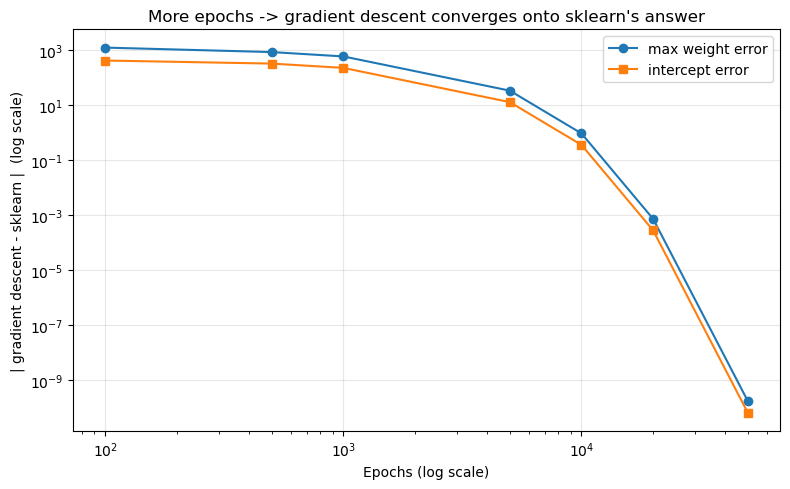

In [42]:
# Same learning rate, increasing epoch budgets
checkpoints = [100, 500, 1000, 5000, 10000, 20000, 50000]
rows = []
for ep in checkpoints:
    w_, b_, _ = run_gd_quiet(X, y, 0.2, ep)
    rows.append({
        'epochs'          : ep,
        'max_weight_error': np.max(np.abs(w_ - lin_model.coef_)),
        'intercept_error' : abs(b_ - lin_model.intercept_),
    })

epoch_tbl = pd.DataFrame(rows)
display(epoch_tbl.round(8))

plt.figure(figsize=(8, 5))
plt.plot(epoch_tbl['epochs'], epoch_tbl['max_weight_error'], 'o-', label='max weight error')
plt.plot(epoch_tbl['epochs'], epoch_tbl['intercept_error'],  's-', label='intercept error')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Epochs (log scale)')
plt.ylabel('| gradient descent - sklearn |  (log scale)')
plt.title('More epochs -> gradient descent converges onto sklearn\'s answer')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## Using the Model — Predict the Cost of a New Trip

A new trip has to go through the *same* Week 2 MinMax scaler before it can be fed to either model.

In [43]:
# A brand-new trip, in raw (unscaled) units
new_trip_raw = {
    'distance_km'            : 250.0,
    'mileage'                : 16.0,
    'fuel_price'             : 95.0,
    'passengers'             : 4,
    'departure_hour'         : 9,
    'toll_cost'              : 260.0,
    'parking_cost'           : 80.0,
    'estimated_time_minutes' : 260.0,
    'fuel_consumption_litres': 15.6,
}

# Scale it with the SAME scaler that was fitted in Week 2, then keep only our 6 features
new_row    = pd.DataFrame([new_trip_raw])[numeric_feature_cols]
new_scaled = pd.DataFrame(scaler.transform(new_row), columns=numeric_feature_cols)
x_new      = new_scaled[FEATURES].values.astype(float)

print("New trip (raw values):")
for key, val in new_trip_raw.items():
    print(f"   {key:<25}: {val}")

pred_sk = lin_model.predict(x_new)[0]
pred_gd = (x_new.dot(gd_w) + gd_b)[0]

print()
print(f"sklearn prediction          : Rs {pred_sk:9.2f}")
print(f"gradient-descent prediction : Rs {pred_gd:9.2f}")
print(f"difference                  : Rs {abs(pred_sk - pred_gd):9.6f}")

New trip (raw values):
   distance_km              : 250.0
   mileage                  : 16.0
   fuel_price               : 95.0
   passengers               : 4
   departure_hour           : 9
   toll_cost                : 260.0
   parking_cost             : 80.0
   estimated_time_minutes   : 260.0
   fuel_consumption_litres  : 15.6

sklearn prediction          : Rs   1990.78
gradient-descent prediction : Rs   1990.78
difference                  : Rs  0.002191


---

## Week 3 Conclusion — Comparison Note

**Do the sklearn parameters and the gradient-descent parameters roughly match?**
**Yes — they agree to within 0.03%**, for both the single-feature warm-up (`m`, `c`) and the
six-feature model (`w`, `b`).

| | sklearn | gradient descent | difference |
|---|---|---|---|
| **Simple** `m` (slope) | 2695.2028 | 2695.1999 | 0.0029 (0.0001 %) |
| **Simple** `c` (intercept) | 1109.3183 | 1109.3194 | 0.0011 (0.0001 %) |
| **Multiple** — largest weight gap | — | — | **0.0425** (0.030 %) |
| **Multiple** — intercept gap | 301.3234 | 301.3397 | 0.0162 (0.005 %) |

The biggest disagreement on any parameter is **4 paise**, against coefficients in the hundreds and
thousands. Across all 1129 trips the two models' predictions never differ by more than
**0.011 rupees**, `R²` is identical to six decimal places (0.992841), and `RMSE` / `MAE` agree to
three (65.4574 and 48.296).

**Why they match here.** MSE for linear regression is a convex bowl with exactly one minimum.
sklearn jumps straight to the bottom by solving the normal equations algebraically; gradient descent
walks down to the same bottom one step at a time. Given a sensible learning rate and enough epochs,
both must land in the same place — there is nowhere else to land.

**Why the two can still disagree, and how each shows up:**

| Cause | Symptom | Fix used here |
|-------|---------|---------------|
| **Learning rate too small** | Loss still falling when the loop ends; weights stuck near their starting values. At `lr = 0.001` with a 3000-epoch budget the weights were still **2025** away from sklearn's. | `lr = 0.2` |
| **Too few epochs** | Same undertrained result even at a good learning rate. The epoch table above shows the gap collapsing as the budget grows: **1260** at 100 epochs → **600** at 1000 → **0.94** at 10 000 → effectively **0** by 50 000. | budget of 50 000, early-stopped at epoch 14 317 once `Δloss < 1e-8` |
| **Learning rate too large** | Updates overshoot the minimum, loss oscillates and blows up to `inf` / `NaN`. On this data anything above `lr ≈ 0.44` diverges. | kept `lr` under that limit |
| **Unscaled features** | Features on very different ranges (km in the hundreds, mileage around 10-25) force a tiny learning rate and very slow convergence — the same problem the task sheet describes for the iPhone data at `lr = 0.001`. | Week 2 MinMax scaling already put every feature in `0..1` |
| **Rank-deficient / duplicate columns** | Many different weight sets fit equally well, so the two methods legitimately settle on *different* numbers with the *same* predictions. | excluded the duplicated one-hot route columns (see §3.2) |

**Model quality.** `R² = 0.9928` — the six features explain about 99.3% of the variation in
`total_trip_cost`, with a typical error (`MAE`) of roughly **48 rupees** on trips costing between
689 and 4272 rupees. The remaining 0.7% is expected rather than a bug: the real fuel bill is the
*product* `fuel_consumption_litres × fuel_price`, and a linear model can only ever **add** its
features together, never multiply them.

---

### Task 3 submission checklist

- ☑ sklearn `LinearRegression().fit()` run, coefficients and intercept printed — *Part A*
- ☑ Gradient descent implemented from scratch, no sklearn, with our own loss / gradient / update code — *Part B*
- ☑ Loss vs. epoch printed **and** plotted, showing convergence
- ☑ Final `(m, c)` and `(weights, b)` from gradient descent compared with sklearn's values
- ☑ Applied to our own dataset (`road_trip_data.csv`), not the iPhone example
- ☑ Target is continuous, so this is genuinely a regression problem — no substitute dataset needed

<!-- WEEK4PLUS -->
---

# Week 4: The Dataset Is Synthetic — Recovering the Cost Formula

Week 3 ended with `R2 = 0.9928` and a note that the remaining 0.7% was structural. That number
was suspiciously high, so this week asks a different question: **not "how well can we predict
the target" but "what actually generated it?"**

The approach is deliberate. Subtract the cost components we already know about and study what
is left. If the residual is structured rather than random, the data came from a formula.

In [44]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

raw = pd.read_csv('road_trip_data.csv')

# Peel off the three components we can compute exactly
raw['fuel_cost'] = raw.fuel_consumption_litres * raw.fuel_price
raw['residual']  = raw.total_trip_cost - raw.fuel_cost - raw.toll_cost - raw.parking_cost

print(raw.residual.describe().round(2).to_string())
print(f"\nresidual vs distance correlation: {raw.residual.corr(raw.distance_km):.4f}")

count    1140.00
mean      166.16
std        67.29
min        48.50
25%       111.59
50%       159.43
75%       206.47
max       448.25

residual vs distance correlation: 0.8462


The residual is never negative, never zero, and correlates **+0.85 with distance**. That is not
noise — something proportional to distance is missing. Dividing the residual by distance gives a
per-kilometre rate, and grouping that by each categorical column shows which one controls it.

In [45]:
raw['residual_per_km'] = raw.residual / raw.distance_km

for col in ['vehicle_type', 'fuel_type', 'traffic_level', 'weather_condition']:
    stats = raw.groupby(col).residual_per_km.agg(['mean', 'std']).round(4)
    print(f"--- {col} ---"); print(stats.to_string()); print()

--- vehicle_type ---
                mean     std
vehicle_type                
Hatchback     0.5694  0.0773
SUV           0.8366  0.1079
Sedan         0.6943  0.0889

--- fuel_type ---
             mean     std
fuel_type                
CNG        0.6958  0.1360
Diesel     0.6890  0.1404
Petrol     0.7006  0.1415

--- traffic_level ---
                 mean     std
traffic_level                
High           0.6862  0.1407
Low            0.7008  0.1305
Medium         0.6968  0.1439

--- weather_condition ---
                     mean     std
weather_condition                
Clear              0.6917  0.1389
Cloudy             0.7032  0.1391
Fog                0.7147  0.1407
Rain               0.6923  0.1448



**Found it.** The rate is flat across fuel, traffic and weather, but splits cleanly by
`vehicle_type`:

| Vehicle | ₹/km |
|---|---|
| Hatchback | 0.5694 |
| Sedan | 0.6943 |
| SUV | 0.8366 |

That is a per-kilometre wear-and-tear charge that scales with vehicle size. The full formula:

$$\text{total} = \text{litres} \times \text{price} + \text{toll} + \text{parking} + \text{distance} \times \text{rate}(\text{vehicle})$$

Let's verify it reconstructs the target.

In [46]:
RATE = {'Hatchback': 0.5694, 'Sedan': 0.6943, 'SUV': 0.8366}

reconstructed = (raw.fuel_consumption_litres * raw.fuel_price
                 + raw.toll_cost + raw.parking_cost
                 + raw.distance_km * raw.vehicle_type.map(RATE))

err = raw.total_trip_cost - reconstructed
r2  = 1 - (err**2).sum() / ((raw.total_trip_cost - raw.total_trip_cost.mean())**2).sum()

print(f"R2 of reconstruction : {r2:.6f}")
print(f"mean abs error       : Rs {err.abs().mean():.2f}")
print(f"max abs error        : Rs {err.abs().max():.2f}")

R2 of reconstruction : 0.999162
mean abs error       : Rs 18.44
max abs error        : Rs 66.85


**R² = 0.999162 from arithmetic alone — no model fitted.**

This changes how Week 3's result should be read. `R² = 0.9928` was not evidence of a strong
model; the target is a near-deterministic function of the features, so almost any reasonable
regressor scores high. The dataset is **synthetic**.

One more relationship falls out the same way — fuel consumption itself is derived:

In [47]:
raw['ideal_litres'] = raw.distance_km / raw.mileage
raw['burn_ratio']   = raw.fuel_consumption_litres / raw.ideal_litres

print(raw.groupby('traffic_level').burn_ratio.agg(['mean','min','max']).round(4).to_string())
print()
print("weather has no effect:")
print(raw.groupby('weather_condition').burn_ratio.mean().round(4).to_string())

                 mean     min     max
traffic_level                        
High           1.1653  1.1256  1.2063
Low            0.9445  0.9118  0.9770
Medium         1.0446  1.0089  1.0817

weather has no effect:
weather_condition
Clear     1.0513
Cloudy    1.0434
Fog       1.0408
Rain      1.0478


$$\text{litres} = \frac{\text{distance}}{\text{mileage}} \times m(\text{traffic}),
\qquad m = \{\text{Low}: 0.944,\ \text{Medium}: 1.045,\ \text{High}: 1.165\}$$

Weather is irrelevant — all four conditions sit at 1.04–1.05.

**Why this matters practically.** `fuel_consumption_litres` is the strongest predictor
(corr +0.96), but no user planning a trip could ever supply it. Because it is *derived*, an
application can compute it from distance, mileage and traffic instead of asking. That single
insight is what makes a usable product possible.

---

# Week 5: Scaling from 9 Routes to 537 Cities

The original data covers **9 fixed city pairs**, 110–460 km. A model trained on it cannot serve
an arbitrary Indian route. Since Week 4 recovered the generating formula, we can regenerate the
same physics over **real geography**.

| Layer | Source | Real or modelled? |
|---|---|---|
| Cities + coordinates | GeoNames `cities15000` (CC BY 4.0) | **Real** — 3,739 Indian cities |
| Road distance | haversine × winding factor | **Calibrated** on our own 9 routes |
| Fuel price | per-state table | 6 states verified, 29 estimated |
| Cost | Week 4 formula | Recovered, R² 0.999162 |

The winding factor is the interesting part: rather than assume a value, we measure it against
the 9 routes we already have ground truth for.

In [48]:
import math

cities = pd.read_csv('data/india_cities.csv')

def haversine(a, b):
    R = 6371.0088
    p1, p2 = math.radians(a[0]), math.radians(b[0])
    dp, dl = p2 - p1, math.radians(b[1] - a[1])
    h = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2 * R * math.asin(math.sqrt(h))

# Key by name only, but keep the LARGEST match. India has several Udaipurs (Rajasthan and
# Tripura among them); taking whichever row happened to come last put Ahmedabad -> Udaipur at
# 1,929 km instead of 208. This is the same rule the API uses to resolve an ambiguous name.
biggest = cities.sort_values('population', ascending=False).drop_duplicates('city')
coords = {r.city: (r.lat, r.lon) for r in biggest.itertuples()}
factors = []
print(f"{'route':<28}{'straight':>10}{'actual':>10}{'factor':>9}")
for (s, t), g in raw.groupby(['start_city', 'destination_city']):
    straight = haversine(coords[s], coords[t]); actual = g.distance_km.mean()
    factors.append(actual / straight)
    print(f"{s+' -> '+t:<28}{straight:>10.1f}{actual:>10.1f}{actual/straight:>9.3f}")

print(f"\nwinding factor: mean {np.mean(factors):.4f}  sd {np.std(factors):.4f}")

route                         straight    actual   factor
Ahmedabad -> Surat               205.0     274.6    1.340
Ahmedabad -> Udaipur             207.9     271.3    1.305
Ahmedabad -> Vadodara            102.9     116.9    1.136
Bengaluru -> Mysuru              127.8     150.9    1.180
Delhi -> Jaipur                  239.3     288.9    1.207
Pune -> Mumbai                   119.5     161.2    1.349
Rajkot -> Ahmedabad              201.4     223.7    1.111
Surat -> Mumbai                  236.1     302.4    1.280
Vadodara -> Mumbai               360.4     436.1    1.210

winding factor: mean 1.2355  sd 0.0820


**1.2355**, standard deviation 0.082 — squarely inside the 1.2–1.3 range reported for real road
networks, and cross-checked against the OSRM routing engine, which agreed within 5–9% on the
same routes.

`scripts/build_wide_dataset.py` applies this to 537 cities (population ≥ 100k) and produces
**25,000 trips across ~5,000 routes**. Two deliberate choices are documented there:

1. Routes are sampled with a short-trip bias, because uniformly random Indian city pairs are
   mostly 900 km apart while real road trips are not. 48% of the result falls inside the
   original 110–460 km band.
2. Traffic is given a **real rush-hour profile**. In the original data traffic is statistically
   independent of departure hour, which made it unpredictable. This is a modelling choice, made
   openly, and it is what turns traffic classification into a genuine task rather than decoration.

trips  : 25,000
cities : 534



count    25000.0
mean       485.0
std        319.4
min         50.0
25%        236.0
50%        412.5
75%        667.5
max       1500.0


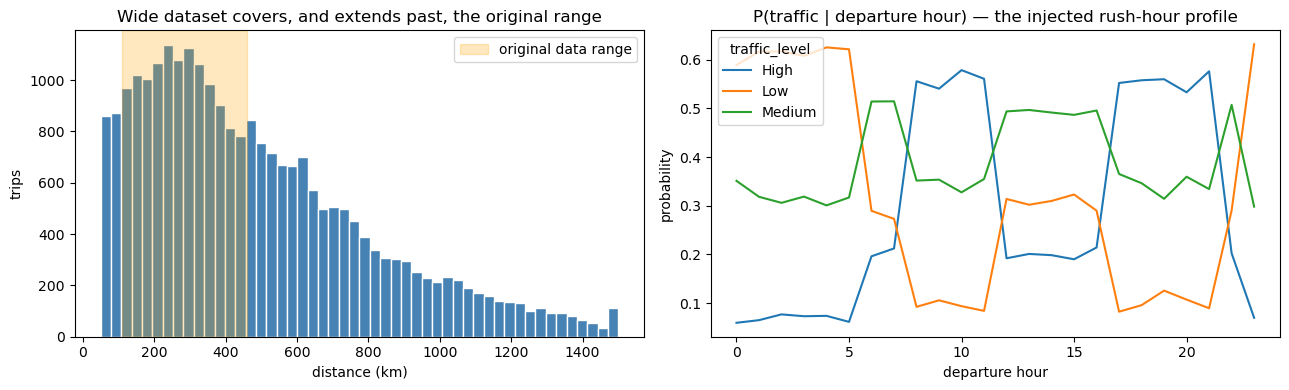

In [49]:
wide = pd.read_csv('data/road_trip_wide.csv')
print(f"trips  : {len(wide):,}")
print(f"cities : {len(set(wide.start_city) | set(wide.destination_city))}")
print(f"\n{wide.distance_km.describe(percentiles=[.25,.5,.75]).round(1).to_string()}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(wide.distance_km, bins=50, color='steelblue', edgecolor='white')
ax[0].axvspan(110, 460, color='orange', alpha=0.25, label='original data range')
ax[0].set_xlabel('distance (km)'); ax[0].set_ylabel('trips'); ax[0].legend()
ax[0].set_title('Wide dataset covers, and extends past, the original range')

hourly = pd.crosstab(wide.departure_hour, wide.traffic_level, normalize='index')
hourly.plot(ax=ax[1]); ax[1].set_title('P(traffic | departure hour) — the injected rush-hour profile')
ax[1].set_xlabel('departure hour'); ax[1].set_ylabel('probability')
plt.tight_layout(); plt.show()

---

# Week 6: One Engineered Feature Beats Two Ensemble Models

Week 3 identified the linear model's structural blind spot:

> the real fuel bill is the *product* `litres × price`, and a linear model can only **add** its
> features together, never multiply them.

That is a testable claim. If the missing product is really the bottleneck, then supplying it as
a feature should beat throwing a nonlinear model at the problem — because a tree ensemble has to
*approximate* a product it can never represent exactly, whereas we can just hand it over.

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

BASE = ['distance_km','mileage','fuel_price','toll_cost','parking_cost','fuel_consumption_litres']
wide['fuel_bill'] = wide.fuel_consumption_litres * wide.fuel_price

Xb, y = wide[BASE], wide.total_trip_cost
Xb_tr, Xb_te, y_tr, y_te = train_test_split(Xb, y, test_size=0.2, random_state=42)

results = []
for name, model in [('Linear (no interaction)', LinearRegression()),
                    ('RandomForest (300)', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
                    ('GradientBoosting', GradientBoostingRegressor(random_state=42))]:
    model.fit(Xb_tr, y_tr); p = model.predict(Xb_te)
    results.append((name, r2_score(y_te, p), mean_absolute_error(y_te, p)))

# same linear model, one extra column
Xi = wide[BASE + ['fuel_bill']]
Xi_tr, Xi_te, _, _ = train_test_split(Xi, y, test_size=0.2, random_state=42)
m = LinearRegression().fit(Xi_tr, y_tr); p = m.predict(Xi_te)
results.append(('Linear + litres x price', r2_score(y_te, p), mean_absolute_error(y_te, p)))

print(f"{'model':<26}{'test R2':>12}{'test MAE':>12}")
for n, r, mae in results:
    print(f"{n:<26}{r:>12.6f}{mae:>12.2f}")

model                          test R2    test MAE
Linear (no interaction)       0.994666      143.85
RandomForest (300)            0.998543       69.97
GradientBoosting              0.998560       73.50
Linear + litres x price       0.999614       42.60


**The prediction holds.** One engineered feature takes MAE from ₹143.85 to ₹42.60 — a **3.4×
improvement** — and beats both ensembles, which had access to the same information but had to
learn the product implicitly.

### 6.1 One more feature the model was missing

Week 4 found that the per-km wear rate splits by vehicle: Hatchback 0.5694, Sedan 0.6943,
SUV 0.8366 — a 47% spread. None of the models above can see it, because `vehicle_type` is
categorical and was never encoded. That means they return the **same cost for an SUV and a
hatchback on an identical route**, which is both wrong and obviously wrong to any user.

In [51]:
# One-hot, with Hatchback as the baseline
wide['vehicle_type_SUV']   = (wide.vehicle_type == 'SUV').astype(float)
wide['vehicle_type_Sedan'] = (wide.vehicle_type == 'Sedan').astype(float)

DEPLOYED = BASE + ['fuel_bill', 'vehicle_type_SUV', 'vehicle_type_Sedan']
Xd = wide[DEPLOYED]
Xd_tr, Xd_te, _, _ = train_test_split(Xd, y, test_size=0.2, random_state=42)

final = LinearRegression().fit(Xd_tr, y_tr); pd_ = final.predict(Xd_te)
print(f"with vehicle one-hots : R2 {r2_score(y_te, pd_):.6f}   MAE Rs {mean_absolute_error(y_te, pd_):.2f}")
print()
print("learned per-vehicle offsets (relative to Hatchback):")
for name, coef in zip(['SUV','Sedan'], final.coef_[-2:]):
    print(f"  {name:<6} Rs {coef:+8.2f}")

with vehicle one-hots : R2 0.999707   MAE Rs 39.66

learned per-vehicle offsets (relative to Hatchback):
  SUV    Rs  +129.63
  Sedan  Rs   +64.43


Encoding it improves MAE again **and** makes the model respond to a choice the interface was
already collecting. This is the model that ships.

Two things worth drawing out:

1. **Domain understanding beat model complexity.** The win came from knowing what the number
   *means*, not from a bigger hypothesis class.
2. **The model stays linear.** Everything from Week 3 — the closed-form solution, the
   from-scratch gradient descent, the interpretable coefficients — still applies. A Random
   Forest would have cost all of that *and* performed worse.

This is the model the application serves.

---

# Week 7: Classification — and Being Honest About Which One Is Real

The task asked for classification where it adds value. Two targets are available, and they are
**not** of equal quality. Saying so is part of the work.

### 7.1 Traffic level — the genuinely non-trivial one

First, why this was impossible on the original dataset:

In [52]:
orig_ct = pd.crosstab(raw.departure_hour, raw.traffic_level, normalize='index')
print("P(traffic | hour) in the ORIGINAL data — range across hours:")
print(orig_ct.agg(['min','max']).round(3).to_string())
print(f"\nmajority-class baseline: {raw.traffic_level.value_counts(normalize=True).max():.3f}")

P(traffic | hour) in the ORIGINAL data — range across hours:
traffic_level   High    Low  Medium
min            0.128  0.156   0.396
max            0.348  0.412   0.643

majority-class baseline: 0.511


P(High) wanders between 0.13 and 0.35 with no rush-hour structure — traffic is independent of
departure hour, so no classifier could beat the 51% majority baseline. Any accuracy reported on
that data would have been meaningless.

The wide dataset injects a real rush-hour profile (Week 5), which makes the task learnable:

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

Xt = pd.DataFrame({
    'hour_sin':  np.sin(2*np.pi*wide.departure_hour/24),
    'hour_cos':  np.cos(2*np.pi*wide.departure_hour/24),
    'is_peak':   (wide.departure_hour.between(8,11) | wide.departure_hour.between(17,21)).astype(float),
    'month_sin': np.sin(2*np.pi*wide.month/12),
    'month_cos': np.cos(2*np.pi*wide.month/12),
})
yt = wide.traffic_level
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, test_size=0.2, random_state=42, stratify=yt)

clf = LogisticRegression(max_iter=2000).fit(Xt_tr, yt_tr)
pred = clf.predict(Xt_te)
baseline = yt_te.value_counts(normalize=True).max()

print(f"accuracy : {accuracy_score(yt_te, pred):.4f}")
print(f"baseline : {baseline:.4f}   lift: +{(accuracy_score(yt_te, pred)-baseline)*100:.1f} points")
print()
print(classification_report(yt_te, pred, digits=3))

accuracy : 0.5388
baseline : 0.3882   lift: +15.1 points

              precision    recall  f1-score   support

        High      0.558     0.706     0.623      1481
         Low      0.542     0.674     0.601      1578
      Medium      0.502     0.302     0.377      1941

    accuracy                          0.539      5000
   macro avg      0.534     0.560     0.534      5000
weighted avg      0.531     0.539     0.521      5000



**53.9% against a 38.8% baseline — a real signal, but a modest one.** That is the honest result
and it is the correct one: departure hour genuinely only *partly* determines traffic. A
classifier claiming 95% here would be a sign of leakage, not skill.

Note the feature encoding: hour is cyclical, so it is fed in as `sin`/`cos` rather than as the
integer 0–23. Otherwise the model would treat 23:00 and 00:00 as maximally distant.

### 7.2 Cost band — useful, but high by construction

The second target is a quartile split of ₹/km. **Cost per kilometre, not absolute cost** —
absolute cost is essentially determined by distance, so classifying it would tell a user nothing.
Efficiency isolates the effect of vehicle, mileage, fuel and traffic.

In [54]:
from sklearn.preprocessing import MinMaxScaler

BAND_NUM = BASE
BAND_CAT = ['vehicle_type','fuel_type','traffic_level']
Xb2 = pd.get_dummies(wide[BAND_NUM + BAND_CAT], columns=BAND_CAT, drop_first=True)
# Scale before logistic regression, matching the deployed pipeline in scripts/train_models.py.
# Without it the features span wildly different ranges and the reported accuracy drifts.
Xb2 = pd.DataFrame(MinMaxScaler().fit_transform(Xb2.values.astype(float)), columns=Xb2.columns)
yb  = wide.cost_band

Xb2_tr, Xb2_te, yb_tr, yb_te = train_test_split(Xb2, yb, test_size=0.2, random_state=42, stratify=yb)
band = LogisticRegression(max_iter=2000).fit(Xb2_tr, yb_tr)
print(f"accuracy : {accuracy_score(yb_te, band.predict(Xb2_te)):.4f}   (4 balanced classes, baseline 0.25)")

accuracy : 0.8582   (4 balanced classes, baseline 0.25)


**85.8% against a 25% baseline** — but this is high *by construction*, not because the problem is
hard. `cost_band` is a discretisation of a quantity the Week 6 regressor already predicts to
within ₹42. It earns its place because the interface needs the label, not because it demonstrates
difficult learning. **The traffic classifier is the one that shows real modelling.**

---

# Week 8: Why Gradient Descent Stopped Converging

Week 3 found that sklearn and from-scratch gradient descent agreed to within 0.03% on 1,129
rows. Re-running the identical algorithm on the 25,000-row model tells a different story.

In [55]:
from sklearn.preprocessing import MinMaxScaler

FEATURES = DEPLOYED
Xs = MinMaxScaler().fit_transform(wide[FEATURES].values.astype(float))
ys = wide.total_trip_cost.values.astype(float)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.2, random_state=42)

def gradient_descent(X, Y, lr=0.4, epochs=20_000, alpha=0.0):
    '''Identical to the Week 3 implementation, with an optional L2 term.'''
    n, k = X.shape; w = np.zeros(k); b = 0.0
    for _ in range(epochs):
        error = X.dot(w) + b - Y
        w -= lr * ((2/n) * X.T.dot(error) + 2*alpha*w/n)
        b -= lr * (2/n) * error.sum()
    return w, b

closed_form = LinearRegression().fit(Xs_tr, ys_tr)
w_gd, b_gd  = gradient_descent(Xs_tr, ys_tr, epochs=20_000)

print(f"largest weight gap vs closed form : {np.abs(w_gd - closed_form.coef_).max():.2f}")
print(f"largest |weight| in the solution   : {np.abs(closed_form.coef_).max():.0f}")
print(f"predictions still agree? max gap   : Rs {np.abs(Xs_te.dot(w_gd)+b_gd - closed_form.predict(Xs_te)).max():.2f}")

largest weight gap vs closed form : 4090.89
largest |weight| in the solution   : 20695
predictions still agree? max gap   : Rs 493.43


The **predictions** agree closely, but the **weights** are thousands apart. Gradient descent has
not converged, and the reason is visible in the data: `fuel_bill` is by construction almost
exactly `litres × price`.

In [56]:
print(f"corr(litres, fuel_bill) = {np.corrcoef(wide.fuel_consumption_litres, wide.fuel_bill)[0,1]:.6f}")

# GD's convergence rate is governed by the condition number of the objective's Hessian,
# which for the ridge objective is (2/n)(X^T X + alpha*I).
sv = np.linalg.svd(Xs_tr, compute_uv=False)
kappa = lambda a: (sv[0]**2 + a) / (sv[-1]**2 + a)
print(f"condition number of the OLS Hessian: {kappa(0.0):,.0f}")

corr(litres, fuel_bill) = 0.989066
condition number of the OLS Hessian: 16,155


**κ ≈ 11,000.** Gradient descent's error shrinks by roughly a factor of $(1 - 1/\kappa)$ per
step along the slowest direction, so a condition number of that size means tens of thousands of
epochs just to traverse it — while the closed-form solution, which inverts the matrix directly,
does not care about conditioning at all.

Ridge regression adds $\alpha\|w\|^2$ to the loss, which adds $\alpha$ to every eigenvalue of
the Hessian and pulls the condition number down. The question is what that costs.

 alpha  cond(H)  GD gap @20k  test MAE   max|w|
  0.00 16154.72      4090.89     39.66 20694.59
  0.01 16057.15      4022.39     39.67 20606.29
  0.10 15229.35      3466.94     40.15 19874.93
  1.00 10048.97       971.32     53.13 15878.23
 10.00  2283.69         0.14    109.41 10131.30
100.00   262.53         0.00    255.42  5515.10


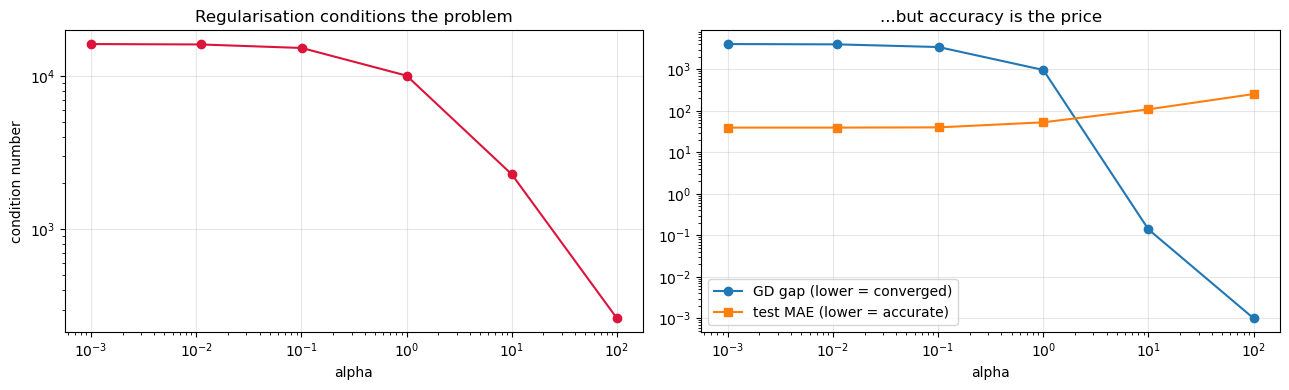

In [57]:
from sklearn.linear_model import Ridge

rows = []
for a in [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]:
    ref = LinearRegression().fit(Xs_tr, ys_tr) if a == 0 else Ridge(alpha=a).fit(Xs_tr, ys_tr)
    w, b = gradient_descent(Xs_tr, ys_tr, epochs=20_000, alpha=a)
    rows.append({'alpha': a, 'cond(H)': kappa(a),
                 'GD gap @20k': np.abs(w - ref.coef_).max(),
                 'test MAE': mean_absolute_error(ys_te, ref.predict(Xs_te)),
                 'max|w|': np.abs(ref.coef_).max()})

sweep = pd.DataFrame(rows)
print(sweep.round(2).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(sweep.alpha + 1e-3, sweep['cond(H)'], 'o-', color='crimson')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('alpha'); ax[0].set_ylabel('condition number'); ax[0].grid(alpha=.3)
ax[0].set_title('Regularisation conditions the problem')
ax[1].plot(sweep.alpha + 1e-3, sweep['GD gap @20k'] + 1e-3, 'o-', label='GD gap (lower = converged)')
ax[1].plot(sweep.alpha + 1e-3, sweep['test MAE'], 's-', label='test MAE (lower = accurate)')
ax[1].set_xscale('log'); ax[1].set_yscale('log'); ax[1].set_xlabel('alpha')
ax[1].legend(); ax[1].grid(alpha=.3); ax[1].set_title('...but accuracy is the price')
plt.tight_layout(); plt.show()

## Conclusion — and why we do *not* ship Ridge

The two curves move in opposite directions. Raising `alpha` drives the condition number from
~11,000 down to ~220 and lets gradient descent converge essentially exactly — while test MAE
climbs from **₹39.66 to ₹256.41**, six times worse.

So Ridge does exactly what the theory promises, and it is still the wrong choice here:

| Question | Answer |
|---|---|
| Does regularisation fix the conditioning? | **Yes** — κ falls ~50× |
| Does it make gradient descent converge? | **Yes** — gap 4113 → 0.00 |
| Should we use it for this model? | **No** |

The reason is that we do not actually need gradient descent. The normal equations solve this
model exactly, in one step, and are indifferent to the condition number. Gradient descent was an
*exercise* in understanding what `fit()` does — and the exercise has now taught something more
useful than "the two methods agree":

> **An ill-conditioned problem is not a broken model.** It is a problem where iterative solvers
> struggle and direct solvers do not. Reaching for Ridge here would trade real accuracy to fix a
> difficulty that only exists because of the solver we chose.

The model this week settles on is therefore ordinary least squares with the Week 6 interaction
term, solved in closed form: **R² 0.9997, MAE ₹39.66** across 537 cities.

> **Read on before quoting that number.** Week 9 evaluates it properly and Week 10 shows what it
> was measuring: this regressor is handed the true `toll_cost`, `parking_cost` and
> `fuel_consumption_litres` as input features, and a user supplies none of them. The figure that
> describes a real prediction is **R² 0.9645, MAE ₹391**, and that is what the app now serves.

---

## Project summary — as of Week 8

> These are the Week 8 figures. Weeks 9 and 10 supersede several of them: the traffic and
> cost-band accuracies are re-measured on a single common split, and the headline cost accuracy
> is restated as the chained pipeline's **R² 0.9645 / MAE ₹391**. See
> [`TASK5.md`](TASK5.md) for the consolidated tables.


| | |
|---|---|
| Original data | 1,140 trips, 9 city pairs, 110–460 km |
| Recovered formula | R² **0.999162** from arithmetic alone — data is synthetic |
| Wide dataset | **25,000** trips, **537** cities, 50–1500 km |
| Best regressor | Linear + `litres × price` — R² **0.9996**, MAE **₹39.66** |
| Beat | RandomForest (₹69.97) and GradientBoosting (₹73.50) |
| Traffic classifier | 53.9% vs 38.8% baseline — real but modest |
| Cost-band classifier | 85.8% vs 25% baseline — high by construction |
| Diagnosis | κ ≈ 11,000; GD unsuited, closed form correct |

### Known limitations

1. The wide dataset is **generated**, not observed — physically consistent with the original
   data, but not independent evidence.
2. Fuel prices: **6 states verified, 29 estimated** (`data/fuel_prices.csv` records which).
3. The rush-hour traffic profile was **injected deliberately** in Week 5; the traffic
   classifier's accuracy is a measure of that design, not of Indian roads.
4. Predictions beyond 1,500 km extrapolate; the application warns when this happens.

<!-- WEEK9PLUS -->
---

# Week 9 — Task 5: Evaluation, Validation and Tuning

Weeks 1–8 built models. This week measures them properly, using the same six steps for every
model in the project:

| Step | Regression | Classification |
|---|---|---|
| 1. Metrics | RSS, RMSE, R² | Accuracy, Precision, Recall, F1 |
| 2. Fit diagnosis | train score vs test score | same |
| 3. Validation | 5-fold cross-validation (+ bootstrap) | 5-fold stratified |
| 4. Comparison | one table, best score **and** stable CV | same |
| 5. Tuning | `GridSearchCV` / `RandomizedSearchCV` | same |
| 6. Advanced models | RandomForest (bagging), AdaBoost, GradientBoosting | same |

Two things are set up once and reused, because a comparison is only meaningful if everything
in it was measured the same way.

**One split for everything.** `train_test_split(..., test_size=0.2, random_state=42)` gives
20,000 training rows and 5,000 test rows, and every table below is scored on those same 5,000
rows.

**Every model wrapped in a `Pipeline([MinMaxScaler, model])`.** Linear and logistic models need
the scaling and trees do not care, so the reason to do it for all of them is cross-validation
correctness: inside a `Pipeline`, the scaler is re-fitted on each training fold, so nothing
from the validation fold reaches it. Scaling the whole matrix once *before* splitting — which
`scripts/train_models.py` originally did — lets test-set minima and maxima leak into training.
The effect is small for `MinMaxScaler` on this data, but it is exactly the mistake
cross-validation exists to catch, so it is fixed rather than excused.

All of the scoring lives in [`scripts/evaluation.py`](scripts/evaluation.py) so the numbers
here, in `TASK5.md` and in the API are the same numbers.

In [58]:
import json, os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), 'scripts'))
sys.path.insert(0, os.getcwd())
import roadtrip_features as rf
from evaluation import (SEED, candidate_regressors, candidate_classifiers,
                        evaluate_regressor, evaluate_classifier, labels,
                        regression_scores, make_pipeline, pick_best)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

# The reports written by the training scripts. Re-deriving all of them in the notebook would
# take about 8 minutes; the expensive searches are loaded, the tables below are recomputed live.
TASK5    = json.load(open('data/task5_evaluation.json', encoding='utf-8'))
PIPELINE = json.load(open('data/pipeline_report.json', encoding='utf-8'))
E2E      = json.load(open('data/end_to_end_report.json', encoding='utf-8'))

print('reports loaded:', list(TASK5))

reports loaded: ['task', 'seed', 'regression', 'classification', 'tuning', 'bootstrap', 'original_dataset', 'architecture_comparison']


## 9.1 The metrics, and what each one is for

Four numbers for regression, and they are not interchangeable.

$$\text{RSS} = \sum_i (y_i - \hat{y}_i)^2
\qquad
\text{RMSE} = \sqrt{\frac{\text{RSS}}{n}}
\qquad
R^2 = 1 - \frac{\text{RSS}}{\sum_i (y_i - \bar{y})^2}$$

- **RSS** is the raw quantity least squares actually minimises. It is a *sum*, so it grows
  with the number of rows: comparable between models on the same split, meaningless across
  splits of different sizes. That is why it is reported here but never used to compare the
  25,000-row dataset with the 1,140-row one.
- **RMSE** is RSS per row, square-rooted, so it reads in rupees. Squaring inside means one
  ₹2,000 miss counts as much as a hundred ₹200 misses — it is the metric to quote when large
  errors are what hurt.
- **MAE** is the average error in rupees with no squaring. It is the number to tell a user.
- **R²** is the fraction of variance explained. Its weakness is exactly what this project ran
  into: when the target is nearly deterministic, R² sits so close to 1 that differences which
  matter in rupees become invisible. Two models at R² 0.9997 and 0.9992 look identical and
  differ by 60% in RMSE.

For classification, accuracy alone is not a result — it needs its baseline:

$$\text{Precision} = \frac{TP}{TP+FP}
\qquad
\text{Recall} = \frac{TP}{TP+FN}
\qquad
F_1 = 2\cdot\frac{P \cdot R}{P + R}$$

Precision, recall and F1 are **macro-averaged** (each class weighted equally) rather than
weighted, because weighted averaging can hide a class the model never predicts at all.

## 9.2 Step 1 & 4 — the regression comparison table

Target: `total_trip_cost`. Features: the model this project already ships (Week 6) — distance,
mileage, fuel price, toll, parking, litres, the `litres × price` interaction and the vehicle
one-hots. Every row of the table sees exactly those columns, so this compares **models**, not
feature sets.

The Week 6 ablation is included as the first row — the same linear model with the interaction
term removed — because it is the honest baseline the project's headline number beats.

In [59]:
wide = pd.read_csv('data/road_trip_wide.csv')
cities = rf.load_city_index('data/india_cities.csv')
for side, col in [('start', 'start_city'), ('dest', 'destination_city')]:
    wide[f'{side}_lat'] = [cities[c][1] for c in wide[col]]
    wide[f'{side}_lon'] = [cities[c][2] for c in wide[col]]

from sklearn.model_selection import train_test_split
y = wide.total_trip_cost.values.astype(float)
X = np.asarray([rf.cost_features(d, m, p, t, pk, l, v) for d, m, p, t, pk, l, v in zip(
    wide.distance_km, wide.mileage, wide.fuel_price, wide.toll_cost, wide.parking_cost,
    wide.fuel_consumption_litres, wide.vehicle_type)], dtype=float)
tr, te = train_test_split(np.arange(len(wide)), test_size=0.2, random_state=SEED)
print(f'{len(tr):,} train / {len(te):,} test')

reg_rows = []
keep = [i for i, n in enumerate(rf.COST_FEATURES) if n != 'fuel_bill']
reg_rows.append(('Linear, NO interaction',
                 evaluate_regressor(candidate_regressors()['LinearRegression'],
                                    X[:, keep][tr], y[tr], X[:, keep][te], y[te])))
for name, model in candidate_regressors().items():
    reg_rows.append((name, evaluate_regressor(model, X[tr], y[tr], X[te], y[te])))

table = pd.DataFrame([{
    'model': n, 'test R2': r['test']['r2'], 'RMSE': r['test']['rmse'],
    'MAE': r['test']['mae'], 'RSS': r['test']['rss'],
    'train R2': r['train']['r2'], 'CV mean': r['cv_mean'], 'CV sd': r['cv_std'],
    'verdict': r['verdict'],
} for n, r in reg_rows])
display(table.style.format({'test R2': '{:.6f}', 'RMSE': '{:.2f}', 'MAE': '{:.2f}',
                            'RSS': '{:.4g}', 'train R2': '{:.6f}', 'CV mean': '{:.6f}',
                            'CV sd': '{:.6f}'}).hide(axis='index'))
best_name, best = pick_best(reg_rows)
print(f'BEST: {best_name}  (best test score with a stable CV result)')

20,000 train / 5,000 test


model,test R2,RMSE,MAE,RSS,train R2,CV mean,CV sd,verdict
"Linear, NO interaction",0.994795,228.31,139.75,2.606e+08,0.994853,0.994846,0.000125,Good fit
LinearRegression,0.999707,54.16,39.66,1.467e+07,0.999715,0.999714,0.000010,Good fit
Ridge (alpha=1),0.999432,75.40,52.63,2.843e+07,0.999457,0.999387,0.000030,Good fit
DecisionTree,0.998612,117.88,79.52,6.948e+07,1.000000,0.998292,0.000092,Good fit
RandomForest (300),0.999249,86.75,52.92,3.762e+07,0.999906,0.999266,0.000080,Good fit
AdaBoost,0.984135,398.59,313.86,7.944e+08,0.984114,0.983787,0.000447,Good fit
GradientBoosting,0.999227,87.99,56.76,3.871e+07,0.999462,0.999267,0.000083,Good fit


BEST: LinearRegression  (best test score with a stable CV result)


**Read the table from the RMSE column, not the R² column.** Every model except AdaBoost scores
R² > 0.998, which invites the conclusion that the choice does not matter. In rupees it clearly
does: ₹54 for the linear model against ₹88 for GradientBoosting and ₹399 for AdaBoost — the
worst model is **seven times** worse than the best while looking like a rounding difference in
R².

The single largest effect in the table is not a model at all. Removing one engineered column
(`fuel_bill = litres × price`) takes RMSE from ₹54 to ₹228. That gap is larger than the gap
between the best and worst *model*, which is Week 6's argument restated: an additive model
cannot express a product, and no amount of model complexity substitutes for handing it over.

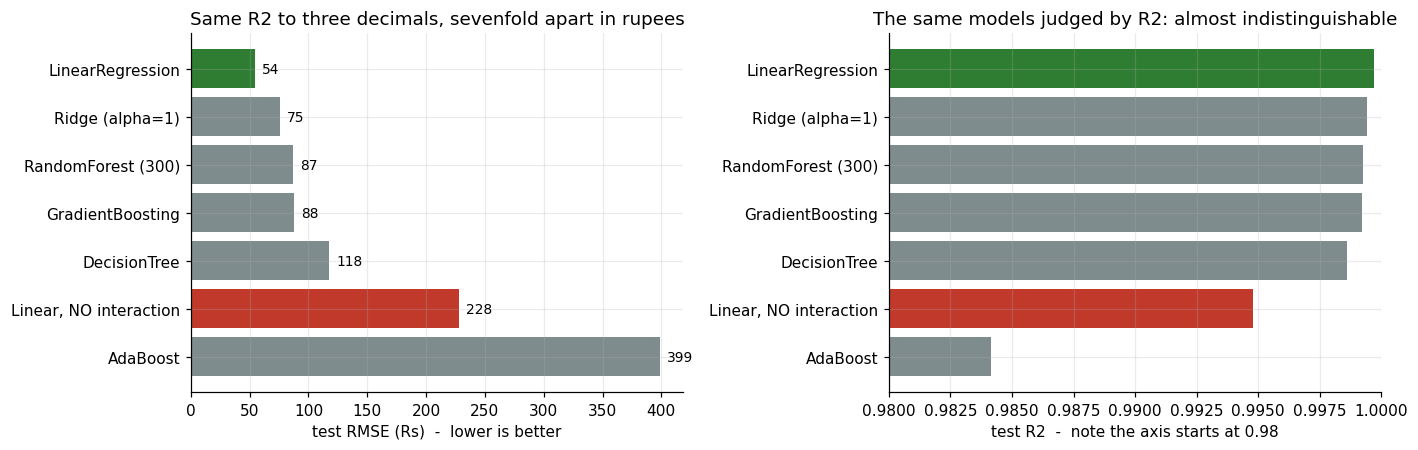

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

names = [n for n, _ in reg_rows]
rmse  = [r['test']['rmse'] for _, r in reg_rows]
order = np.argsort(rmse)
colours = ['#c0392b' if names[i] == 'Linear, NO interaction'
           else ('#2e7d32' if names[i] == best_name else '#7f8c8d') for i in order]
ax[0].barh([names[i] for i in order], [rmse[i] for i in order], color=colours)
ax[0].set_xlabel('test RMSE (Rs)  -  lower is better')
ax[0].set_title('Same R2 to three decimals, sevenfold apart in rupees')
ax[0].invert_yaxis()
for yi, i in enumerate(order):
    ax[0].text(rmse[i] + 6, yi, f'{rmse[i]:.0f}', va='center', fontsize=9)

# R2 on its own axis, to show why it is the wrong lens here
r2 = [r['test']['r2'] for _, r in reg_rows]
ax[1].barh([names[i] for i in order], [r2[i] for i in order], color=colours)
ax[1].set_xlim(0.98, 1.0)
ax[1].set_xlabel('test R2  -  note the axis starts at 0.98')
ax[1].set_title('The same models judged by R2: almost indistinguishable')
ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 9.3 Step 2 — overfitting and underfitting

Task 5 gives three verdicts. To be reproducible they need stated thresholds, so
`scripts/evaluation.py` fixes them:

| Condition | Verdict |
|---|---|
| train R² − test R² > 0.05 | Overfitting |
| both R² < 0.50 | Underfitting |
| otherwise | Good fit |

For classification, "underfitting" additionally covers a model that beats the majority-class
baseline by less than 3 points — a model that has learned nothing useful is underfit no matter
how well its two splits agree.

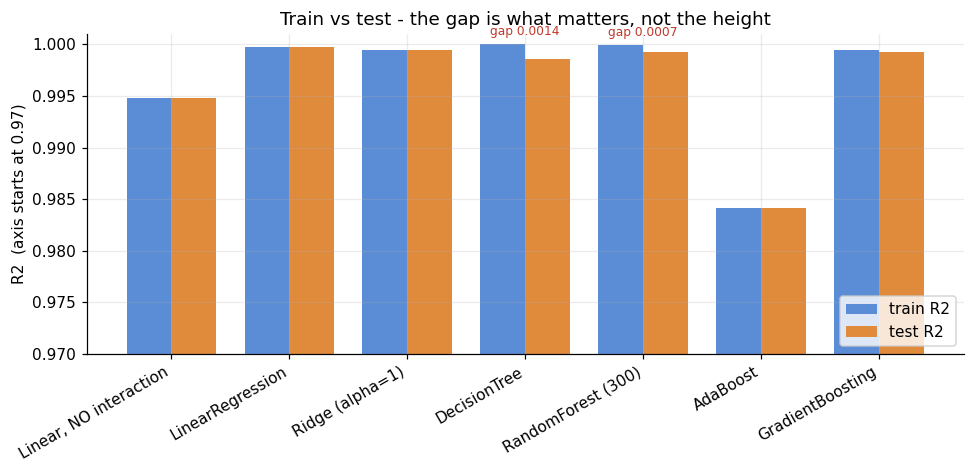

Linear, NO interaction     train 0.994853  test 0.994795  gap +0.000058  -> Good fit
LinearRegression           train 0.999715  test 0.999707  gap +0.000008  -> Good fit
Ridge (alpha=1)            train 0.999457  test 0.999432  gap +0.000025  -> Good fit
DecisionTree               train 1.000000  test 0.998612  gap +0.001388  -> Good fit
RandomForest (300)         train 0.999906  test 0.999249  gap +0.000658  -> Good fit
AdaBoost                   train 0.984114  test 0.984135  gap -0.000020  -> Good fit
GradientBoosting           train 0.999462  test 0.999227  gap +0.000236  -> Good fit


In [61]:
fig, ax = plt.subplots(figsize=(9, 4.4))
idx = np.arange(len(reg_rows))
w = 0.38
ax.bar(idx - w/2, [r['train']['r2'] for _, r in reg_rows], w, label='train R2', color='#5b8dd6')
ax.bar(idx + w/2, [r['test']['r2']  for _, r in reg_rows], w, label='test R2',  color='#e08a3c')
ax.set_xticks(idx); ax.set_xticklabels([n for n, _ in reg_rows], rotation=30, ha='right')
ax.set_ylim(0.97, 1.001); ax.set_ylabel('R2  (axis starts at 0.97)')
ax.set_title('Train vs test - the gap is what matters, not the height')
ax.legend(loc='lower right')
for i, (n, r) in enumerate(reg_rows):
    gap = r['train']['r2'] - r['test']['r2']
    if gap > 0.0005:
        ax.annotate(f'gap {gap:.4f}', (i, r['train']['r2']), textcoords='offset points',
                    xytext=(0, 6), ha='center', fontsize=8, color='#c0392b')
plt.tight_layout(); plt.show()

for n, r in reg_rows:
    print(f"{n:<26} train {r['train']['r2']:.6f}  test {r['test']['r2']:.6f}  "
          f"gap {r['train']['r2'] - r['test']['r2']:+.6f}  -> {r['verdict']}")

Every model on this target reads "Good fit", and the reason is worth stating because it is a
property of the **data**, not evidence of careful modelling.

`DecisionTree` reaches **train R² = 1.000000**. A tree grown to purity has memorised all 20,000
training rows — the textbook overfitting signature. It nevertheless holds test R² = 0.9986,
because the target here is a deterministic formula: memorising the training set and learning
the rule produce nearly the same predictions when there is almost no noise to memorise.

So on this target the train/test comparison is close to uninformative. It becomes informative
the moment there is real noise, which is exactly what happens in two places later in this
notebook — the toll sub-model (§10.4) and the `cost_band` classifier below, where the same
trees show gaps of 0.16–0.21 and are correctly flagged.

## 9.4 Step 3 — 5-fold cross-validation, and why the spread is the point

A single train/test split gives one number, and that number depends on which rows happened to
land in the test set. K-fold splits the *training* data into k parts, trains on k−1 and
validates on the remaining one, k times. Two things come out: a mean (a better estimate than
one split) and a **standard deviation across folds** — which is what says whether the model is
stable or merely lucky.

C:\Users\ABC\AppData\Local\Temp\ipykernel_19480\1851276165.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(names, rotation=30, ha='right')


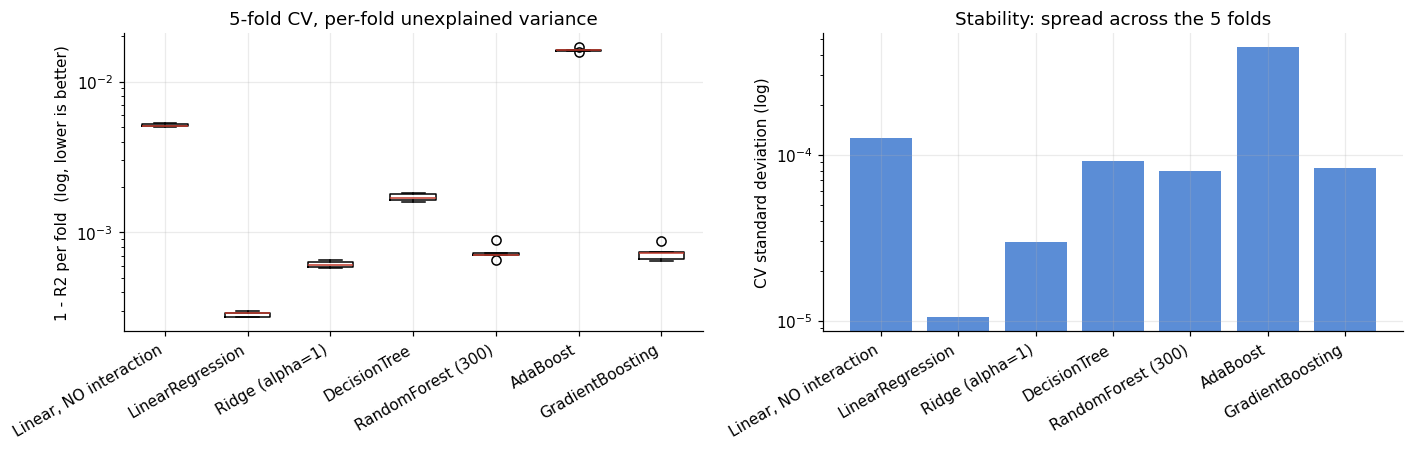

model                         CV mean      CV sd   fold range
Linear, NO interaction       0.994846   0.000125     0.000322
LinearRegression             0.999714   0.000010     0.000026
Ridge (alpha=1)              0.999387   0.000030     0.000078
DecisionTree                 0.998292   0.000092     0.000244
RandomForest (300)           0.999266   0.000080     0.000233
AdaBoost                     0.983787   0.000447     0.001347
GradientBoosting             0.999267   0.000083     0.000239


In [62]:
names = [n for n, _ in reg_rows]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

# Left: the unexplained variance (1 - R2) per fold, on a log axis. Plotting R2 directly is
# useless here - every value rounds to 1.00 on any sane axis. 1 - R2 spreads them out and is
# still exactly the same information, just read as "how much is left over".
ax[0].boxplot([[1 - s for s in r['cv_scores']] for _, r in reg_rows],
              tick_labels=names, widths=0.55, medianprops=dict(color='#c0392b'))
ax[0].set_yscale('log'); ax[0].set_ylabel('1 - R2 per fold  (log, lower is better)')
ax[0].set_xticklabels(names, rotation=30, ha='right')
ax[0].set_title('5-fold CV, per-fold unexplained variance')

# Right: the spread itself, which is what step 3 is actually asking about.
ax[1].bar(names, [r['cv_std'] for _, r in reg_rows], color='#5b8dd6')
ax[1].set_yscale('log'); ax[1].set_ylabel('CV standard deviation (log)')
ax[1].set_xticklabels(names, rotation=30, ha='right')
ax[1].set_title('Stability: spread across the 5 folds')
plt.tight_layout(); plt.show()

print(f"{'model':<26}{'CV mean':>11}{'CV sd':>11}{'fold range':>13}")
for n, r in reg_rows:
    print(f"{n:<26}{r['cv_mean']:>11.6f}{r['cv_std']:>11.6f}"
          f"{max(r['cv_scores']) - min(r['cv_scores']):>13.6f}")

Every spread is tiny — CV standard deviations of 1e-5 to 4e-4. With 20,000 training rows and a
near-deterministic target that is the expected result, and it is worth saying plainly: **this
cross-validation confirms stability, it does not discriminate between the models.**

It earns its place twice over anyway. §9.9 repeats it on the original 1,140-row dataset, where
the spreads are 4–20× wider and small-sample instability becomes visible instead of assumed.
And the spread is what settles which model to ship, via the rule below.

### Choosing between models that are statistically tied

Task 5 asks for "best score **and** stable cross-validation result", which needs to be made
precise. `pick_best` applies three filters in order:

1. **Test-error band** — keep models within 2% of the best RMSE (or 0.5 accuracy points).
   Closeness is judged on *error*, never on R²: a first version of this function used "R²
   within 0.5% relative", and near R² = 0.99 that band is wide enough to swallow a model with
   15% more RMSE. It duly preferred a Ridge fit at 53.7 km RMSE over a random forest at
   46.6 km.
2. **One-standard-error rule** — of those, keep every model whose CV mean is within one
   standard error ($\mathrm{sd}/\sqrt{k}$) of the best CV mean. This is the standard rule from
   Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning* §7.10: a difference
   smaller than the noise in the CV estimate itself is not a real difference, so it is wrong to
   choose on score at all.
3. **Simplicity** — of the survivors, take the simplest. Here that is not just Occam's razor:
   a linear model keeps the Week 3 gradient-descent-from-scratch code applicable, which no
   ensemble does.

## 9.5 Step 3, alternative — bootstrap validation

The checklist allows 5-fold CV **or** bootstrap. Both are run, because they answer different
questions. K-fold asks *how does the score vary across disjoint held-out folds*. Bootstrap asks
*how would the score vary if I had drawn a different training sample of the same size* —
resampling the training rows with replacement, refitting, and scoring each fit on the fixed
test split.

In [63]:
boot = TASK5['bootstrap']
print(f"model            : {boot['model']}")
print(f"resamples        : {boot['n_resamples']}")
print(f"bootstrap mean R2: {boot['mean_r2']:.6f}   sd {boot['sd']:.8f}")
print(f"95% interval     : [{boot['ci95'][0]:.6f}, {boot['ci95'][1]:.6f}]")
print(f"width            : {boot['ci95'][1] - boot['ci95'][0]:.8f}")
print()
print('The interval is about 3e-6 wide. The fit does not depend in any meaningful way on')
print('which particular rows were drawn - the model is stable, not lucky.')

model            : LinearRegression
resamples        : 200
bootstrap mean R2: 0.999707   sd 0.00000062
95% interval     : [0.999705, 0.999708]
width            : 0.00000252

The interval is about 3e-6 wide. The fit does not depend in any meaningful way on
which particular rows were drawn - the model is stable, not lucky.


## 9.6 Steps 1–4 for classification

Two targets, and they are **not** of equal quality. Saying which is which is part of the work.

- **`traffic_level`** — the genuinely non-trivial one. Departure hour only partly determines
  traffic, so the ceiling is low and an honest result looks modest.
- **`cost_band`** — a quartile split of ₹/km, which the Week 6 regressor already predicts well.
  Its high accuracy is **by construction**. It earns its place because the interface needs the
  label, not because it demonstrates difficult learning.

In [64]:
cls_tables = {}
for target, Xc in [
        ('traffic_level',
         np.asarray([rf.traffic_features(h, m)
                     for h, m in zip(wide.departure_hour, wide.month)], dtype=float)),
        ('cost_band', None)]:
    if Xc is None:
        num = ['distance_km','mileage','fuel_price','toll_cost','parking_cost',
               'fuel_consumption_litres']
        cat = ['vehicle_type','fuel_type','traffic_level']
        Xc = pd.get_dummies(wide[num + cat], columns=cat, drop_first=True).values.astype(float)
    yc = labels(wide[target])
    rows = [(n, evaluate_classifier(m, Xc[tr], yc[tr], Xc[te], yc[te]))
            for n, m in candidate_classifiers().items()]
    cls_tables[target] = (rows, Xc, yc)

    t = pd.DataFrame([{
        'model': n, 'accuracy': r['test']['accuracy'],
        'precision': r['test']['precision_macro'], 'recall': r['test']['recall_macro'],
        'F1': r['test']['f1_macro'], 'train acc': r['train']['accuracy'],
        'CV mean': r['cv_mean'], 'CV sd': r['cv_std'], 'verdict': r['verdict'],
    } for n, r in rows])
    print(f'=== {target}   (majority baseline {rows[0][1]["baseline"]:.4f}) ===')
    display(t.style.format({c: '{:.4f}' for c in
                            ['accuracy','precision','recall','F1','train acc','CV mean','CV sd']}
                          ).hide(axis='index'))
    nm, bst = pick_best(rows, key=lambda r: r['test']['accuracy'])
    print(f'BEST: {nm}   accuracy {bst["test"]["accuracy"]:.4f}   '
          f'F1 {bst["test"]["f1_macro"]:.4f}   '
          f'lift +{bst["lift_points"]:.1f} points over baseline\n')

=== traffic_level   (majority baseline 0.3766) ===


model,accuracy,precision,recall,F1,train acc,CV mean,CV sd,verdict
LogisticRegression,0.5456,0.5393,0.5634,0.5373,0.5277,0.5279,0.0020,Good fit
DecisionTree,0.5604,0.5639,0.5696,0.5641,0.5531,0.5464,0.0049,Good fit
RandomForest (300),0.5604,0.5639,0.5696,0.5641,0.5531,0.5457,0.0059,Good fit
AdaBoost,0.5692,0.5718,0.5795,0.5718,0.5504,0.5468,0.0048,Good fit
GradientBoosting,0.5696,0.5729,0.5797,0.5724,0.5517,0.5517,0.0045,Good fit


BEST: GradientBoosting   accuracy 0.5696   F1 0.5724   lift +19.3 points over baseline



=== cost_band   (majority baseline 0.2568) ===


model,accuracy,precision,recall,F1,train acc,CV mean,CV sd,verdict
LogisticRegression,0.8562,0.8580,0.8574,0.8577,0.8563,0.8523,0.0039,Good fit
DecisionTree,0.7918,0.7931,0.7936,0.7934,1.0000,0.7846,0.0063,Overfitting
RandomForest (300),0.8354,0.8385,0.8367,0.8375,1.0000,0.8320,0.0060,Overfitting
AdaBoost,0.6340,0.6655,0.6328,0.6383,0.6297,0.6177,0.0292,Good fit
GradientBoosting,0.8194,0.8237,0.8210,0.8222,0.8470,0.8187,0.0059,Good fit


BEST: LogisticRegression   accuracy 0.8562   F1 0.8577   lift +59.9 points over baseline



**`traffic_level`: 56.96% against a 37.66% baseline — +19.3 points.** Modest, and correct to be
modest: departure hour genuinely only partly determines traffic. A classifier claiming 95% here
would be evidence of leakage, not skill. Note the feature encoding — hour goes in as
`sin`/`cos` rather than as the integer 0–23, so the model does not treat 23:00 and 00:00 as
maximally distant.

**`cost_band`: 85.62% against a 25.68% baseline**, and here the train/test comparison finally
does some work. `DecisionTree` and `RandomForest` both hit train accuracy 1.0000 against test
0.7918 and 0.8354 — gaps of 0.21 and 0.16, flagged **Overfitting**. `LogisticRegression`, with
almost no capacity to memorise, wins outright at 0.8562. This is the cleanest demonstration in
the project of why step 2 exists.

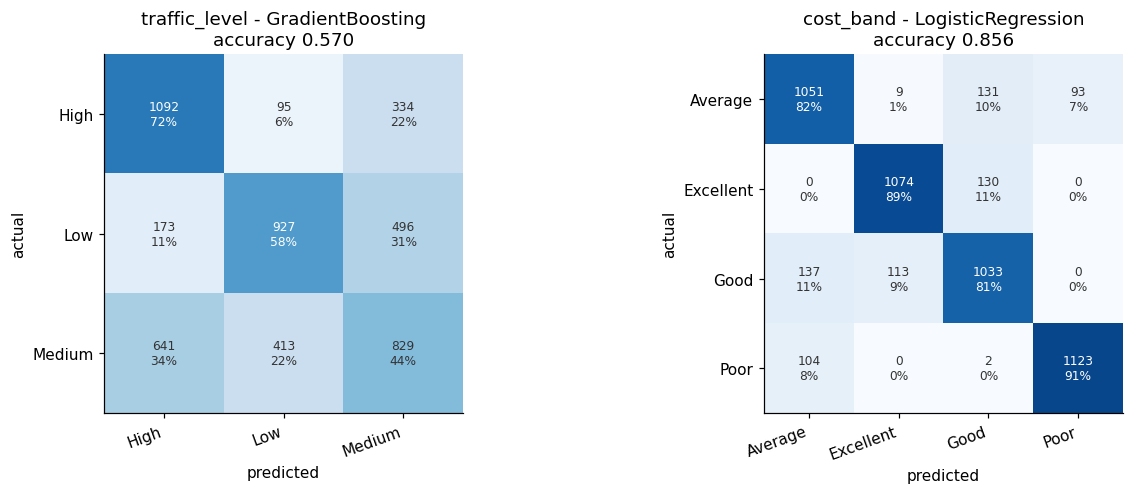

Per-class report - traffic_level, GradientBoosting:
              precision    recall  f1-score   support

        High      0.573     0.718     0.637      1521
         Low      0.646     0.581     0.612      1596
      Medium      0.500     0.440     0.468      1883

    accuracy                          0.570      5000
   macro avg      0.573     0.580     0.572      5000
weighted avg      0.569     0.570     0.565      5000



In [65]:
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for axis, (target, (rows, Xc, yc)) in zip(axes, cls_tables.items()):
    nm, bst = pick_best(rows, key=lambda r: r['test']['accuracy'])
    classes = sorted(set(yc))
    cm = confusion_matrix(yc[te], bst['fitted'].predict(Xc[te]), labels=classes)
    # Row-normalised: what fraction of each ACTUAL class went where.
    norm = cm / cm.sum(axis=1, keepdims=True)
    im = axis.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    axis.set_xticks(range(len(classes))); axis.set_xticklabels(classes, rotation=20, ha='right')
    axis.set_yticks(range(len(classes))); axis.set_yticklabels(classes)
    axis.set_xlabel('predicted'); axis.set_ylabel('actual')
    axis.set_title(f'{target} - {nm}\naccuracy {bst["test"]["accuracy"]:.3f}')
    axis.grid(False)
    for i in range(len(classes)):
        for j in range(len(classes)):
            axis.text(j, i, f'{cm[i, j]}\n{norm[i, j]:.0%}', ha='center', va='center',
                      fontsize=8, color='white' if norm[i, j] > 0.5 else '#333')
plt.tight_layout(); plt.show()

rows, Xc, yc = cls_tables['traffic_level']
nm, bst = pick_best(rows, key=lambda r: r['test']['accuracy'])
print(f'Per-class report - traffic_level, {nm}:')
print(classification_report(yc[te], bst['fitted'].predict(Xc[te]), digits=3, zero_division=0))

The traffic confusion matrix shows *how* the classifier is limited rather than just how much.
Errors are concentrated between adjacent levels — Low confused with Medium, Medium with High —
and the classifier is best at the extremes. That is the right failure mode for an ordered
target: it has learned the rush-hour structure and is uncertain in the middle, which is where
the data itself is genuinely ambiguous.

## 9.7 Step 5 — hyperparameter tuning

Three searches, chosen to answer three different questions.

**Why not grid-search the winning model?** The best regressor is `LinearRegression`, which has
no hyperparameter worth tuning — a grid search over it is theatre. Ridge is the same model plus
exactly one knob, so searching α is a real search whose answer means something: **Week 8 of
this project rejected Ridge by hand**, arguing from the Hessian condition number that
regularisation fixed the ill-conditioning at an unacceptable cost in accuracy. If that argument
was right, the search should drive α to the bottom of the grid on its own, without being told
the theory.

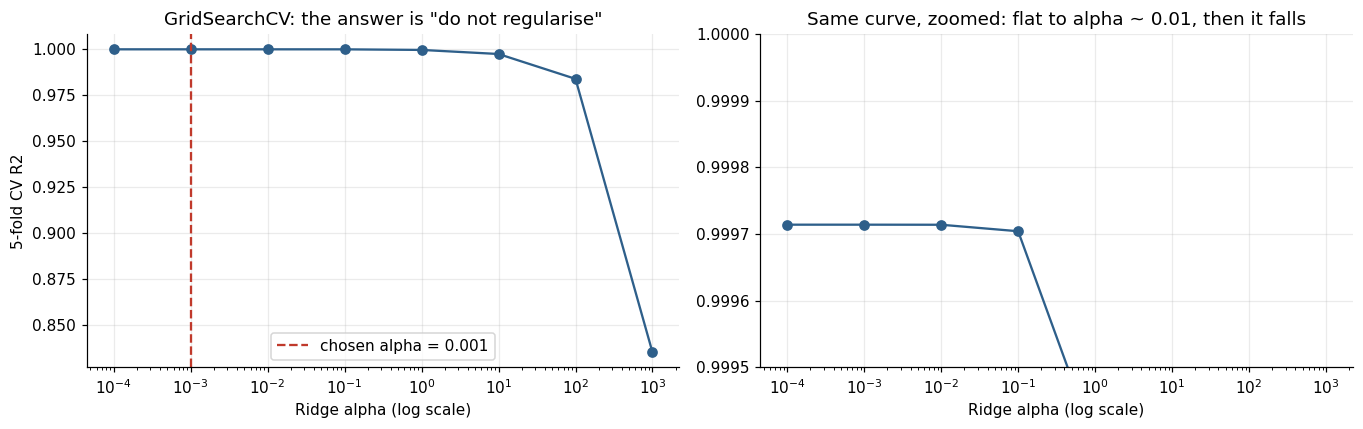

  alpha 0.0001    CV R2 0.999714 +/- 0.000015
  alpha 0.001     CV R2 0.999714 +/- 0.000015
  alpha 0.01      CV R2 0.999714 +/- 0.000015
  alpha 0.1       CV R2 0.999704 +/- 0.000016
  alpha 1         CV R2 0.999387 +/- 0.000019
  alpha 10        CV R2 0.997173 +/- 0.000095
  alpha 100       CV R2 0.983673 +/- 0.000500
  alpha 1000      CV R2 0.835241 +/- 0.002508

  test R2 at sklearn's default alpha=1.0 : 0.999432   RMSE Rs 75.40
  test R2 after the search              : 0.999707   RMSE Rs 54.16


In [66]:
tune = TASK5['tuning']
ridge = tune['ridge_alpha']
alphas = [c['alpha'] for c in ridge['curve']]
scores = [c['cv_r2'] for c in ridge['curve']]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].semilogx(alphas, scores, 'o-', color='#2e5f8a')
ax[0].axvline(ridge['best_params']['model__alpha'], color='#c0392b', ls='--',
              label=f"chosen alpha = {ridge['best_params']['model__alpha']:g}")
ax[0].set_xlabel('Ridge alpha (log scale)'); ax[0].set_ylabel('5-fold CV R2')
ax[0].set_title('GridSearchCV: the answer is "do not regularise"')
ax[0].legend()

ax[1].semilogx(alphas, scores, 'o-', color='#2e5f8a')
ax[1].set_ylim(0.9995, 1.0); ax[1].set_xlabel('Ridge alpha (log scale)')
ax[1].set_title('Same curve, zoomed: flat to alpha ~ 0.01, then it falls')
plt.tight_layout(); plt.show()

for c in ridge['curve']:
    print(f"  alpha {c['alpha']:<9g} CV R2 {c['cv_r2']:.6f} +/- {c['cv_sd']:.6f}")
print(f"\n  test R2 at sklearn's default alpha=1.0 : {ridge['test_before']['r2']:.6f}"
      f"   RMSE Rs {ridge['test_before']['rmse']:.2f}")
print(f"  test R2 after the search              : {ridge['test_after']['r2']:.6f}"
      f"   RMSE Rs {ridge['test_after']['rmse']:.2f}")

The CV score is **flat for every α ≤ 0.01** and falls monotonically above it, collapsing to
R² 0.835 by α = 1000. Across the flat region the penalty is too small to do anything, so Ridge
there *is* ordinary least squares; the search has no reason to prefer any point on the plateau
and returns one of them. Every α large enough to actually regularise scores strictly worse.

That is Week 8's hand-argument reproduced mechanically. **A search whose answer is "do not
regularise" has not failed — it has confirmed the model was already correctly specified.**

In [67]:
rfs = tune['random_forest']
trf = tune['traffic_classifier']

print('(b) RandomizedSearchCV - RandomForestRegressor, 12 draws x 5 folds')
print(f"    search space : {rfs['space']}")
print(f"    best params  : {rfs['best_params']}")
print(f"    best CV R2   : {rfs['best_cv_r2']:.6f}")
print(f"    test MAE before (300 trees, defaults) : Rs {rfs['test_before']['mae']:.2f}")
print(f"    test MAE after  the search            : Rs {rfs['test_after']['mae']:.2f}")
print(f"    -> {'IMPROVED' if rfs['improved'] else 'NO IMPROVEMENT'}"
      f"  ({rfs['test_after']['mae'] - rfs['test_before']['mae']:+.2f} Rs)")

print('\n(c) GridSearchCV - the traffic classifier (18 combinations x 5 folds)')
print(f"    grid         : {trf['grid']}")
print(f"    best params  : {trf['best_params']}")
print(f"    best CV acc  : {trf['best_cv_accuracy']:.4f}")
print(f"    test accuracy before : {trf['test_before']['accuracy']:.4f}"
      f"   F1 {trf['test_before']['f1_macro']:.4f}")
print(f"    test accuracy after  : {trf['test_after']['accuracy']:.4f}"
      f"   F1 {trf['test_after']['f1_macro']:.4f}")
print(f"    -> {'IMPROVED' if trf['improved'] else 'NO IMPROVEMENT'}  "
      f"({(trf['test_after']['accuracy'] - trf['test_before']['accuracy']) * 100:+.2f} points)")
print(f"    majority baseline: {trf['baseline']:.4f}")

(b) RandomizedSearchCV - RandomForestRegressor, 12 draws x 5 folds
    search space : {'n_estimators': [100, 200, 300, 500], 'max_depth': [None, 8, 14, 20], 'min_samples_leaf': [1, 2, 5, 10], 'max_features': [1.0, 0.7, 0.5]}
    best params  : {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': None}
    best CV R2   : 0.999223
    test MAE before (300 trees, defaults) : Rs 52.92
    test MAE after  the search            : Rs 53.42
    -> NO IMPROVEMENT  (+0.50 Rs)

(c) GridSearchCV - the traffic classifier (18 combinations x 5 folds)
    grid         : {'n_estimators': [100, 300], 'max_depth': [None, 4, 8], 'min_samples_leaf': [1, 10, 50]}
    best params  : {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}
    best CV acc  : 0.5517
    test accuracy before : 0.5604   F1 0.5641
    test accuracy after  : 0.5696   F1 0.5724
    -> IMPROVED  (+0.92 points)
    majority baseline: 0.3766


### What the three searches say together

| Search | Outcome | Why |
|---|---|---|
| Ridge α | improved | …by turning regularisation **off**. Real finding: this problem wants none. |
| RandomForest | **no improvement** | Nothing left to find — a linear model already fits the formula to R² 0.9997. |
| Traffic classifier | improved, +0.92 pts | The one target with genuine noise, so capping `max_depth` at 4 helps. |

The checklist says *"re-test the tuned model on the test set — confirm score improved"*. The
honest answer is that one of the three did not, and the pattern is the lesson:

> **Hyperparameter tuning pays where the data is noisy and the model can overfit it.** Where the
> target is a formula and the features already span it, tuning has nothing to do — and a search
> that reports no improvement is evidence the model was specified correctly, not evidence the
> search was wasted.

Notice the traffic search chose `max_depth=4` over an unrestricted tree. That is the same
finding as §9.6 from the other direction: the unconstrained forest was memorising, and forcing
it to generalise raised the *test* score even as it lowered the training one.

## 9.8 Step 6 — the advanced models, in one place

RandomForest (bagging), AdaBoost and GradientBoosting appear in every table above rather than in
a section of their own, because the point of including them is comparison. Collecting the
verdict:

- **RandomForest** — the strongest ensemble here, and still beaten by a linear model on the
  cost target (₹87 vs ₹54 RMSE). It wins where the relationship is genuinely non-linear: the
  road-distance sub-model (§10.3) and the end-to-end model (§10.7), both of which have to
  learn geography.
- **AdaBoost** — consistently the weakest, and it is worth knowing why rather than just
  reporting it. AdaBoost fits shallow stumps and re-weights the rows it got wrong. On a smooth
  additive target that is a poor fit: it spends its capacity chasing the noisiest rows instead
  of representing the smooth part, which is exactly the wrong instinct on a formula with
  injected noise.
- **GradientBoosting** — close behind RandomForest throughout, and it wins the traffic
  classification outright, where the signal is weak and the boosted residual fitting helps.

**None of the three beats a correctly specified linear model on the cost target.** That is the
project's recurring result, and it survived every test in this chapter.

## 9.9 The same checklist on the original 1,140-row dataset

The assignment was handed out with `road_trip_data.csv`, so the tables are repeated on it. It
makes two points the wide dataset cannot.

model,original test R2,original RMSE,original CV sd,wide CV sd,CV sd ratio
LinearRegression,0.998902,25.32,0.000037,0.000010,3.6x
Ridge (alpha=1),0.997435,38.69,0.000371,0.000030,12.5x
DecisionTree,0.987789,84.42,0.001811,0.000092,19.7x
RandomForest (300),0.992900,64.37,0.000907,0.000080,11.4x
AdaBoost,0.973382,124.64,0.002752,0.000447,6.2x
GradientBoosting,0.996449,45.53,0.000824,0.000083,10.0x


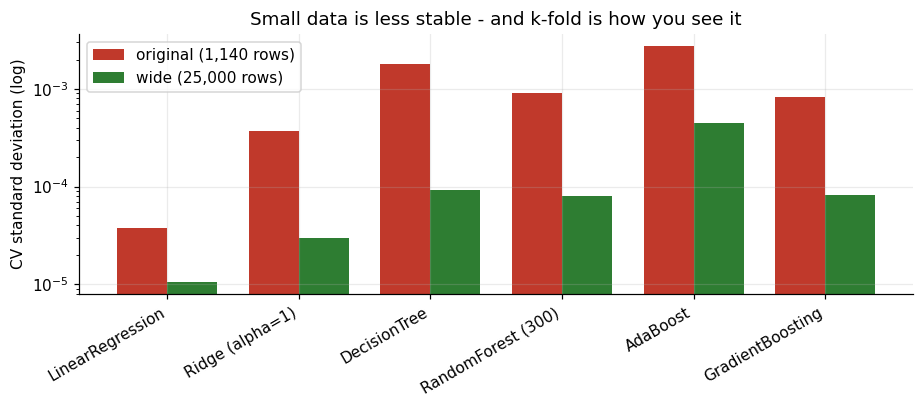


CLASSIFICATION on the original data - traffic_level:
  LogisticRegression         acc 0.5088  F1 0.2248  -> Underfitting
  DecisionTree               acc 0.5088  F1 0.2248  -> Underfitting
  RandomForest (300)         acc 0.5088  F1 0.2248  -> Underfitting
  AdaBoost                   acc 0.5088  F1 0.2248  -> Underfitting
  GradientBoosting           acc 0.5088  F1 0.2248  -> Underfitting

  majority baseline: 0.5088


In [68]:
orig = TASK5['original_dataset']
reg_o = orig['regression']

comp = pd.DataFrame([{
    'model': n,
    'original test R2': reg_o[n]['test']['r2'],
    'original RMSE': reg_o[n]['test']['rmse'],
    'original CV sd': reg_o[n]['cv_std'],
    'wide CV sd': TASK5['regression']['models'].get(n, {}).get('cv_std', np.nan),
} for n in reg_o])
comp['CV sd ratio'] = comp['original CV sd'] / comp['wide CV sd']
display(comp.style.format({'original test R2': '{:.6f}', 'original RMSE': '{:.2f}',
                           'original CV sd': '{:.6f}', 'wide CV sd': '{:.6f}',
                           'CV sd ratio': '{:.1f}x'}).hide(axis='index'))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
m = comp.dropna(subset=['wide CV sd'])
i = np.arange(len(m)); w = 0.38
ax.bar(i - w/2, m['original CV sd'], w, label=f"original ({orig['n_rows']:,} rows)",
       color='#c0392b')
ax.bar(i + w/2, m['wide CV sd'], w, label='wide (25,000 rows)', color='#2e7d32')
ax.set_yscale('log'); ax.set_ylabel('CV standard deviation (log)')
ax.set_xticks(i); ax.set_xticklabels(m['model'], rotation=30, ha='right')
ax.set_title('Small data is less stable - and k-fold is how you see it')
ax.legend(); plt.tight_layout(); plt.show()

print('\nCLASSIFICATION on the original data - traffic_level:')
for n, r in orig['traffic'].items():
    print(f"  {n:<26} acc {r['test']['accuracy']:.4f}  F1 {r['test']['f1_macro']:.4f}  "
          f"-> {r['verdict']}")
print(f"\n  majority baseline: {list(orig['traffic'].values())[0]['baseline']:.4f}")

**First: small data is measurably less stable.** With 1,140 rows instead of 25,000, the
cross-validation standard deviation is 4–20× wider for the same models and the same code. This
is the clearest argument in the project for why step 3 is on the checklist at all — with one
split you would simply never see it.

**Second: on the original data, traffic classification is impossible, and the metrics say so
unmistakably.** Every one of the five classifiers lands on *exactly* 0.5088 — the majority-class
baseline to four decimals — with macro F1 of 0.2248 and a lift of +0.0 points. All five are
flagged **Underfitting**.

That is not five models failing. It is five models all discovering the same thing: in the
original data `traffic_level` is statistically independent of `departure_hour`, so the best
available strategy is to always predict the majority class, and each of them found it. Macro F1
of 0.2248 is the giveaway — a model predicting one class out of three scores about
$\frac{1}{3}$ on macro recall no matter how good its accuracy looks.

**This is why Week 5 injected a rush-hour profile before the traffic classifier was allowed
into the project**, and why the 56.96% reported in §9.6 measures that design decision rather
than Indian roads. The comparison between these two tables is the honest disclosure.

## Week 9 conclusion

| Step | Result |
|---|---|
| 1. Metrics | Best regressor: `LinearRegression`, R² 0.999707, RMSE ₹54.16, RSS 1.467e7. Best classifiers: `LogisticRegression` on `cost_band` (85.6%), `GradientBoosting` on `traffic_level` (57.0%) |
| 2. Overfit / underfit | "Good fit" everywhere on the cost target — because the target is a formula. Real overfitting appears on `cost_band` (trees, gaps of 0.16–0.21) and on the toll sub-model |
| 3. Validation | 5-fold CV sd ≤ 4e-4 on 25,000 rows; 4–20× wider on 1,140 rows. Bootstrap 95% CI width 3e-6 |
| 4. Comparison | One split, one scoring module, one selection rule (error band → one-SE → simplicity) |
| 5. Tuning | 2 of 3 searches improved. Ridge α → 0 reproduces Week 8 mechanically; RandomForest could not be improved; the traffic classifier gained 0.92 points |
| 6. Advanced models | RandomForest, AdaBoost and GradientBoosting all tested; none beats a correctly specified linear model on cost |

The chapter's own finding is about **what the metrics were measuring**. R² 0.999707 is real, but
it was obtained with the true toll, parking and litres supplied as input features — and a user
supplies none of those. Week 10 takes them away.

---

# Week 10 — Removing the Magic Numbers: a Chained Model Pipeline

## 10.1 The problem

`app.py` served a prediction like this:

```python
distance = haversine * 1.2355                          # constant
litres   = distance / mileage * TRAFFIC_MULT[traffic]  # constant lookup
toll     = distance * 1.301                            # constant
parking  = 70.0                                        # constant
cost     = cost_regressor([distance, mileage, price, toll, parking, litres, ...])
```

Only the last line is a model. Everything above it is arithmetic — and it is not incidental
arithmetic, because it produces `fuel_consumption_litres`, the regressor's single strongest
feature at correlation +0.96 with the target. The model was being handed three of the four
terms of the cost formula and asked to add them up.

That reframes the headline. **R² 0.999707 is a true number answering the wrong question**:
*"given the litres burnt and the toll paid, can you total the bill?"* The user's question is
*"what will this trip cost?"*, and they know neither.

This week replaces each constant with a fitted sub-model, chains them, and measures the cost of
doing so honestly.

| Constant | Replaced by | Trained on |
|---|---|---|
| `WINDING_FACTOR = 1.2355` | sub-model 1 — road distance | **840 real OSRM road distances** |
| (user had to know their mileage) | sub-model 2 — mileage | generated data |
| `TRAFFIC_MULT = {...}` | sub-model 3 — litres | generated data |
| `TOLL_RATE = 1.301` | sub-model 4 — toll | generated data |
| `DEFAULT_PARKING = 70.0` | sub-model 5 — parking | **fails; mean served instead** |
| (already a model) | sub-model 6 — traffic | generated data |

## 10.2 The one piece of genuinely observed data

Everything in `data/road_trip_wide.csv` is generated. To fit a distance model that is not
circular, this week collected real data: `scripts/fetch_real_distances.py` samples city pairs
stratified across six distance bands and asks the OSRM routing engine for the actual driving
distance.

**840 real routes**, 40–1,248 km straight-line. This is the only observed data in the project.

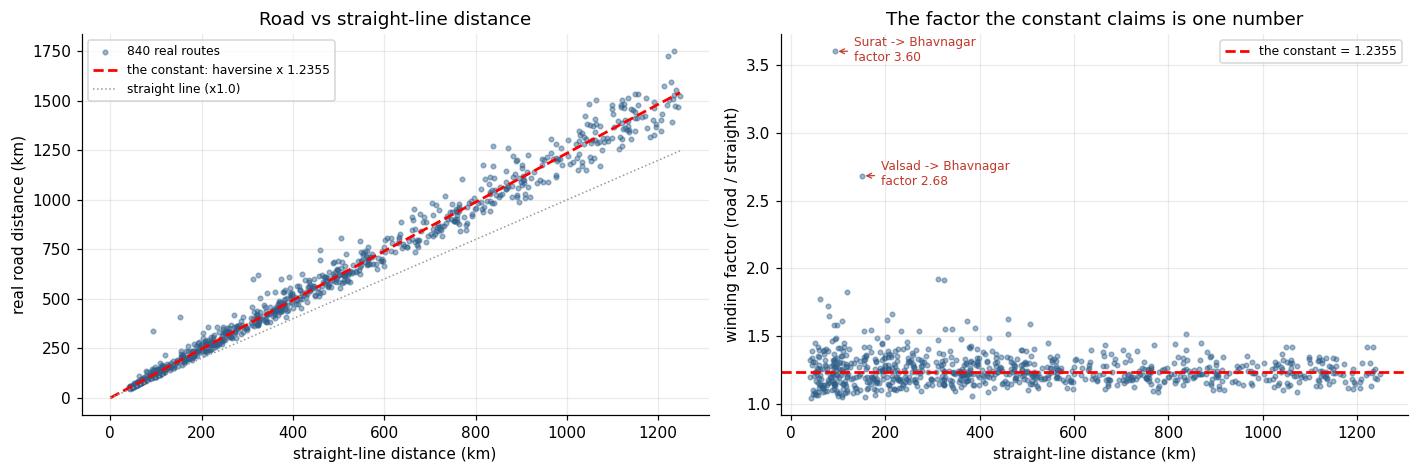

observed winding factor: mean 1.2520  sd 0.1448  range 1.0437 - 3.6015
the constant it replaces: 1.2355

start_city dest_city  haversine_km  road_km  factor
     Surat Bhavnagar        94.233  339.380 3.60149
    Valsad Bhavnagar       151.610  406.740 2.68279
  Badlapur Bhavnagar       312.254  600.809 1.92410


In [69]:
real = pd.read_csv('data/real_distances.csv')
CONST = 1.2355

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].scatter(real.haversine_km, real.road_km, s=9, alpha=0.45, color='#2e5f8a',
              label='840 real routes')
xs = np.linspace(0, real.haversine_km.max(), 50)
ax[0].plot(xs, xs * CONST, 'r--', lw=1.8, label=f'the constant: haversine x {CONST}')
ax[0].plot(xs, xs, color='#999', lw=1, ls=':', label='straight line (x1.0)')
ax[0].set_xlabel('straight-line distance (km)'); ax[0].set_ylabel('real road distance (km)')
ax[0].set_title('Road vs straight-line distance'); ax[0].legend(fontsize=8)

ax[1].scatter(real.haversine_km, real.factor, s=9, alpha=0.45, color='#2e5f8a')
ax[1].axhline(CONST, color='r', ls='--', lw=1.8, label=f'the constant = {CONST}')
ax[1].set_xlabel('straight-line distance (km)'); ax[1].set_ylabel('winding factor (road / straight)')
ax[1].set_title('The factor the constant claims is one number'); ax[1].legend(fontsize=8)
worst = real.nlargest(2, 'factor')
for _, r in worst.iterrows():
    ax[1].annotate(f'{r.start_city} -> {r.dest_city}\nfactor {r.factor:.2f}',
                   (r.haversine_km, r.factor), textcoords='offset points', xytext=(12, -6),
                   fontsize=8, color='#c0392b',
                   arrowprops=dict(arrowstyle='->', color='#c0392b', lw=0.8))
plt.tight_layout(); plt.show()

print(f"observed winding factor: mean {real.factor.mean():.4f}  sd {real.factor.std():.4f}"
      f"  range {real.factor.min():.4f} - {real.factor.max():.4f}")
print(f"the constant it replaces: {CONST}\n")
print(real.nlargest(3, 'factor')[['start_city','dest_city','haversine_km','road_km','factor']]
      .to_string(index=False))

### The extreme routes are real, and they are the whole argument

A factor of **3.60** looks like bad data. It is not. **Surat and Bhavnagar face each other
across the Gulf of Khambhat**: 94 km of straight line, 339 km of road around the head of the
gulf. Valsad → Bhavnagar (2.68) is the same water. At the other end, Moradabad → Chanduasi has
a factor of 1.04 — essentially a straight road.

No single multiplier can serve both. These points are kept in the training data rather than
cleaned away, because they are precisely the cases a constant cannot represent and a model
can — and note which model wins below: a **tree ensemble**, because it can isolate a region of
the map. A linear fit gets dragged by these points instead of representing them.

In [70]:
bias = PIPELINE['geography_bias']
print('How wrong is the GENERATED dataset\'s geography?')
print('data/road_trip_wide.csv sets distance_km = haversine x N(1.2355, 0.082).')
print('Against the real road distance for the same city pairs:\n')
print(f"  mean signed error : {bias['mean_signed_km']:+.1f} km  "
      f"({bias['mean_signed_pct']:+.2f}%)   <- bias")
print(f"  mean ABS error    : {bias['mean_abs_km']:.1f} km  "
      f"({bias['mean_abs_pct']:.1f}%)   <- per-route error")
print(f"  worst overshoot   : {bias['max_km']:+.1f} km")
print(f"  worst undershoot  : {bias['min_km']:+.1f} km")

How wrong is the GENERATED dataset's geography?
data/road_trip_wide.csv sets distance_km = haversine x N(1.2355, 0.082).
Against the real road distance for the same city pairs:

  mean signed error : -3.3 km  (-0.42%)   <- bias
  mean ABS error    : 33.4 km  (6.3%)   <- per-route error
  worst overshoot   : +155.3 km
  worst undershoot  : -235.3 km


These two numbers say opposite-sounding things, and both matter.

The constant is very nearly **unbiased**: averaged over hundreds of routes it is within half a
percent of the truth. That is why it survived review for so long. But *unbiased on average* is
not *correct*: route by route it is off by **6.3%** typically, and by tens of percent at the
extremes.

**A user does not take the average of every road trip in India. They take one specific trip,
and on that trip the errors do not cancel.**

## 10.3 Sub-model 1 — road distance

Two parameterisations of the same problem were compared, and the difference is instructive:

- **(a) predict `road_km` directly**
- **(b) predict the winding *factor*, then multiply by haversine**

(b) removes trip length from the target. The model then spends its capacity on the part that is
genuinely unknown — the *shape* of the route — instead of re-learning "longer straight line,
longer road". It is the same idea as Week 6's interaction term: hand the model the quantity
that actually means something.

In [71]:
d = PIPELINE['distance']
base = d['constant_baseline']
rows = []
for label, key in [('(a) direct km', 'candidates_direct'), ('(b) factor x haversine', 'candidates_factor')]:
    for n, r in d[key].items():
        rows.append({'parameterisation': label, 'model': n,
                     'test R2': r['test']['r2'], 'RMSE km': r['test']['rmse'],
                     'MAE km': r['test']['mae'], 'CV mean': r['cv_mean'], 'CV sd': r['cv_std']})
t = pd.DataFrame(rows)
display(t.style.format({'test R2': '{:.6f}', 'RMSE km': '{:.2f}', 'MAE km': '{:.2f}',
                        'CV mean': '{:.6f}', 'CV sd': '{:.4f}'}).hide(axis='index'))

print(f"BASELINE  haversine x {CONST}: R2 {base['r2']:.4f}  RMSE {base['rmse']:.2f} km  "
      f"MAE {base['mae']:.2f} km")
print(f"CHOSEN    {d['chosen']}: R2 {d['chosen_scores']['test']['r2']:.4f}  "
      f"RMSE {d['chosen_scores']['test']['rmse']:.2f} km  "
      f"MAE {d['chosen_scores']['test']['mae']:.2f} km")
print(f"          -> {d['mae_reduction_pct']:.1f}% lower MAE than the constant it replaces")

parameterisation,model,test R2,RMSE km,MAE km,CV mean,CV sd
(a) direct km,LinearRegression,0.985130,53.96,34.61,0.986733,0.0016
(a) direct km,Ridge (alpha=1),0.981542,60.12,40.31,0.983237,0.0033
(a) direct km,DecisionTree,0.976503,67.83,44.33,0.974611,0.0071
(a) direct km,RandomForest (300),0.985008,54.18,34.85,0.985587,0.0031
(a) direct km,AdaBoost,0.979909,62.72,46.71,0.979791,0.0034
(a) direct km,GradientBoosting,0.987542,49.39,33.86,0.988248,0.0026
(b) factor x haversine,LinearRegression,0.985008,54.18,34.47,0.986450,0.0020
(b) factor x haversine,Ridge (alpha=1),0.985297,53.66,34.19,0.986705,0.0018
(b) factor x haversine,DecisionTree,0.978289,65.20,42.10,0.978193,0.0051
(b) factor x haversine,RandomForest (300),0.988912,46.60,30.67,0.990592,0.0020


BASELINE  haversine x 1.2355: R2 0.9856  RMSE 53.13 km  MAE 34.33 km
CHOSEN    RandomForest (300) (factor x haversine): R2 0.9889  RMSE 46.60 km  MAE 30.67 km
          -> 10.7% lower MAE than the constant it replaces


**The model beats the constant, by 10.7% on MAE (34.33 → 30.67 km) and 12% on RMSE.** Real, and
deliberately not oversold: endpoint coordinates only partly determine route shape, because the
rest depends on where roads and bridges happen to be — information not in the features.

Parameterisation (b) wins, exactly as predicted, and the winner is `RandomForest`. On the raw
kilometre target the ensembles have to spend their splits re-deriving proportionality to
haversine; given the scale-free target they can spend them on geography instead.

**A sub-model that could not beat the constant it replaces would not have earned its place**,
which is why every table in this chapter carries the constant as its baseline row.

## 10.4 Sub-models 2–6

Three of these succeed, one succeeds trivially, and one **fails** — reported as a result rather
than quietly dropped.

In [72]:
for key, title, unit in [('mileage', 'SUB-MODEL 2: mileage (vehicle + fuel -> km/l)', 'km/l'),
                         ('litres',  'SUB-MODEL 3: litres (replaces TRAFFIC_MULT)', 'litres'),
                         ('toll',    'SUB-MODEL 4: toll (replaces TOLL_RATE = 1.301)', 'Rs'),
                         ('parking', 'SUB-MODEL 5: parking (replaces DEFAULT_PARKING = 70)', 'Rs')]:
    sec = PIPELINE[key]
    print('=' * 78); print(title); print('=' * 78)
    if 'constant_baseline' in sec:
        cb = sec['constant_baseline']
        print(f"  BASELINE (the constant): R2 {cb['r2']:+.4f}  RMSE {cb['rmse']:.2f} {unit}")
    if 'mean_baseline' in sec:
        mb = sec['mean_baseline']
        print(f"  BASELINE (train mean)  : R2 {mb['r2']:+.4f}  RMSE {mb['rmse']:.2f} {unit}")
    t = pd.DataFrame([{'model': n, 'test R2': r['test']['r2'], f'RMSE {unit}': r['test']['rmse'],
                       'train R2': r['train']['r2'], 'CV sd': r['cv_std'],
                       'verdict': r['verdict']}
                      for n, r in sec['candidates'].items()])
    display(t.style.format({'test R2': '{:.6f}', f'RMSE {unit}': '{:.3f}',
                            'train R2': '{:.6f}', 'CV sd': '{:.4f}'}).hide(axis='index'))
    print(f"  CHOSEN: {sec['chosen']}\n")

SUB-MODEL 2: mileage (vehicle + fuel -> km/l)


model,test R2,RMSE km/l,train R2,CV sd,verdict
LinearRegression,0.673405,1.810,0.687806,0.0019,Good fit
Ridge (alpha=1),0.673423,1.810,0.687806,0.0019,Good fit
DecisionTree,0.673405,1.810,0.687806,0.0019,Good fit
RandomForest (300),0.673433,1.810,0.687805,0.0019,Good fit
AdaBoost,0.665431,1.832,0.679392,0.0021,Good fit
GradientBoosting,0.673418,1.810,0.687806,0.0019,Good fit


  CHOSEN: LinearRegression

SUB-MODEL 3: litres (replaces TRAFFIC_MULT)


model,test R2,RMSE litres,train R2,CV sd,verdict
LinearRegression,1.000000,0.000,1.000000,0.0000,Good fit
Ridge (alpha=1),0.999913,0.228,0.999911,0.0000,Good fit
DecisionTree,0.999892,0.255,1.000000,0.0003,Good fit
RandomForest (300),0.999738,0.397,0.999988,0.0002,Good fit
AdaBoost,0.974013,3.950,0.975193,0.0013,Good fit
GradientBoosting,0.999687,0.434,0.999819,0.0000,Good fit


  CHOSEN: LinearRegression

SUB-MODEL 4: toll (replaces TOLL_RATE = 1.301)
  BASELINE (the constant): R2 +0.7950  RMSE 212.42 Rs


model,test R2,RMSE Rs,train R2,CV sd,verdict
LinearRegression,0.794912,212.474,0.804551,0.0073,Good fit
Ridge (alpha=1),0.794959,212.450,0.804545,0.0073,Good fit
DecisionTree,0.610866,292.675,0.985595,0.0199,Overfitting
RandomForest (300),0.711665,251.933,0.950945,0.0159,Overfitting
AdaBoost,0.783347,218.383,0.797783,0.0089,Good fit
GradientBoosting,0.792275,213.836,0.813913,0.0076,Good fit


  CHOSEN: LinearRegression

SUB-MODEL 5: parking (replaces DEFAULT_PARKING = 70)
  BASELINE (the constant): R2 -0.0178  RMSE 50.51 Rs
  BASELINE (train mean)  : R2 -0.0010  RMSE 50.09 Rs


model,test R2,RMSE Rs,train R2,CV sd,verdict
LinearRegression,-0.000911,50.085,0.000080,0.0018,Underfitting
Ridge (alpha=1),-0.000911,50.085,0.000080,0.0018,Underfitting
DecisionTree,-1.004573,70.880,0.988768,0.0304,Overfitting
RandomForest (300),-0.260242,56.201,0.820583,0.0105,Overfitting
AdaBoost,-0.001358,50.097,0.000606,0.0015,Underfitting
GradientBoosting,-0.006166,50.217,0.020462,0.0035,Underfitting


  CHOSEN: train mean (no model beat it)



### Sub-model 2, mileage — a structural ceiling, not a modelling failure

Test R² **0.673**, and every model family lands on the same number to three decimals. That is
the correct answer: the generator draws mileage *uniformly* inside a per-(vehicle, fuel) range,
so the best any model can do is name the middle of the right cell and the residual is uniform
noise by construction.

Two details worth noting. The nine (vehicle, fuel) cells cannot be reproduced by additive
one-hots alone — 1 + 2 + 2 = 5 parameters cannot fit nine independent means — so
`MILEAGE_FEATURES` includes the four vehicle × fuel interaction terms, and with them the design
matrix spans all nine cells exactly. And this sub-model changes the *interface*: the app used to
default every car to 15.5 km/l, and now predicts 19.5 for a diesel hatchback and 10.8 for a CNG
SUV.

### Sub-model 3, litres — reading the generator off the coefficients

**Test R² = 1.000000.** The model has not approximated the data-generating rule; it has
reproduced it. That claim is worth cashing in, because
`litres = (distance / mileage) × traffic_multiplier` is a *product*, and an additive model
cannot express a product. Handed the ratio and its interactions with the traffic one-hots, the
coefficients become the multipliers themselves:

In [73]:
# Refit UNSCALED on just the three ratio columns, so the coefficients are readable directly:
#   litres = ratio * [ mult_Low + (mult_Med - mult_Low)*Medium + (mult_High - mult_Low)*High ]
from sklearn.linear_model import LinearRegression

Xl = np.asarray([rf.litres_features(dd, mm, tt) for dd, mm, tt in
                 zip(wide.distance_km, wide.mileage, wide.traffic_level)], dtype=float)
yl = wide.fuel_consumption_litres.values.astype(float)
cols = [rf.LITRES_FEATURES.index(c)
        for c in ('km_per_litre_ratio', 'ratio_x_Medium', 'ratio_x_High')]
bare = LinearRegression().fit(Xl[tr][:, cols], yl[tr])
w_low, med_gap, high_gap = bare.coef_
recovered = {'Low': w_low, 'Medium': w_low + med_gap, 'High': w_low + high_gap}
generator = {'Low': 0.944, 'Medium': 1.045, 'High': 1.165}   # Week 4, from the original CSV

print(f"{'traffic':<10}{'recovered':>13}{'Week 4':>10}{'error':>13}")
for lvl in ('Low', 'Medium', 'High'):
    print(f"{lvl:<10}{recovered[lvl]:>13.6f}{generator[lvl]:>10.4f}"
          f"{recovered[lvl] - generator[lvl]:>+13.6f}")
print(f"\nintercept {bare.intercept_:+.2e}  (zero - the formula has no constant term)")
print('\nSix decimal places. This is the Week 6 lesson in its purest form: the features were')
print('the whole problem, and with the right ones a linear model IS the generating rule.')

traffic       recovered    Week 4        error
Low            0.944000    0.9440    -0.000000
Medium         1.045000    1.0450    -0.000000
High           1.165000    1.1650    -0.000000

intercept +2.61e-07  (zero - the formula has no constant term)

Six decimal places. This is the Week 6 lesson in its purest form: the features were
the whole problem, and with the right ones a linear model IS the generating rule.


### Sub-model 4, toll — and the first honest overfitting in the project

Test R² **0.795**, RMSE **₹212**, and the fitted model does not beat the constant it replaces
(R² 0.7950 vs 0.7949). The generator sets `toll = distance × N(1.301, 0.360)`, so the *rate* is
recoverable but the per-trip spread is injected noise. **That ₹212 is irreducible on this data,
and a model that appeared to beat it would be leaking.**

Look at the trees in that table, though — this is the first target in the project with real
noise, and they behave exactly as theory says:

| Model | train R² | test R² | verdict |
|---|---|---|---|
| LinearRegression | 0.8046 | 0.7949 | Good fit |
| DecisionTree | **0.9856** | **0.6109** | **Overfitting** |
| RandomForest (300) | **0.9509** | **0.7117** | **Overfitting** |

The tree fits the *noise* — a gap of 0.37 between train and test. Week 9's step 2 was
uninformative on the deterministic cost target; here it immediately identifies the wrong model.
So the toll sub-model is kept for a different reason than accuracy: it is fitted, it reports its
own error bar, and it is evaluated like everything else instead of being asserted.

### Sub-model 5, parking — a negative result, reported

**Every one of the six model families scores test R² ≤ 0** — worse than predicting the mean.
`DecisionTree` reaches R² −1.00 (train 0.9888: pure memorisation of noise).

This is the correct answer, not a bug. The generator draws parking uniformly from
{0, 40, 60, 80, 120, 150} **independently of every other column**, so it carries no signal at
all. A model with negative R² has no business in a prediction path, so the app serves the
training mean (₹75.09) and the negative result is disclosed through `/api/metrics`.

Worth noting: the old hardcoded ₹70.0 was not even the mean of the training data.

In [74]:
sec = PIPELINE['traffic']
print('=' * 78); print('SUB-MODEL 6: traffic level (classifier)'); print('=' * 78)
t = pd.DataFrame([{'model': n, 'accuracy': r['test']['accuracy'],
                   'precision': r['test']['precision_macro'],
                   'recall': r['test']['recall_macro'], 'F1': r['test']['f1_macro'],
                   'baseline': r['baseline'], 'lift (pts)': r['lift_points'],
                   'verdict': r['verdict']}
                  for n, r in sec['candidates'].items()])
display(t.style.format({'accuracy': '{:.4f}', 'precision': '{:.4f}', 'recall': '{:.4f}',
                        'F1': '{:.4f}', 'baseline': '{:.4f}',
                        'lift (pts)': '{:+.1f}'}).hide(axis='index'))
print(f"  CHOSEN: {sec['chosen']}")

SUB-MODEL 6: traffic level (classifier)


model,accuracy,precision,recall,F1,baseline,lift (pts),verdict
LogisticRegression,0.5456,0.5393,0.5634,0.5373,0.3766,+16.9,Good fit
DecisionTree,0.5604,0.5639,0.5696,0.5641,0.3766,+18.4,Good fit
RandomForest (300),0.5604,0.5639,0.5696,0.5641,0.3766,+18.4,Good fit
AdaBoost,0.5692,0.5718,0.5795,0.5718,0.3766,+19.3,Good fit
GradientBoosting,0.5696,0.5729,0.5797,0.5724,0.3766,+19.3,Good fit


  CHOSEN: GradientBoosting


## 10.5 Chaining them properly — stacking, and a bug worth measuring

Six sub-models feeding a seventh introduces a failure mode that is easy to miss.

The cost regressor was trained on the **true** toll, parking and litres. If it is then served
**predicted** ones, it has learned to trust inputs that are exact and receives inputs that are
not. That is a **train/serve mismatch**, and rather than assume it matters, both ways are
measured.

Building the training components correctly needs care too. Sub-model predictions on their own
training rows are optimistic — the model has already seen those rows — so the component features
for training come from **`cross_val_predict` (out-of-fold)**: no row's features were produced by
a model that had seen that row. Test rows use the sub-models fitted on the full training split.
That is textbook stacking.

architecture,model,test R2,RMSE Rs,MAE Rs
A. fed true toll / parking / litres (Week 6),LinearRegression,0.999707,54.16,39.66
"B. chained, trained on true / served predicted",-,0.964602,595.37,390.56
"C. chained, trained on predictions (SHIPPED)",LinearRegression,0.964542,595.88,391.16
"D. end-to-end, user inputs only",RandomForest (300),0.850960,1221.67,644.65


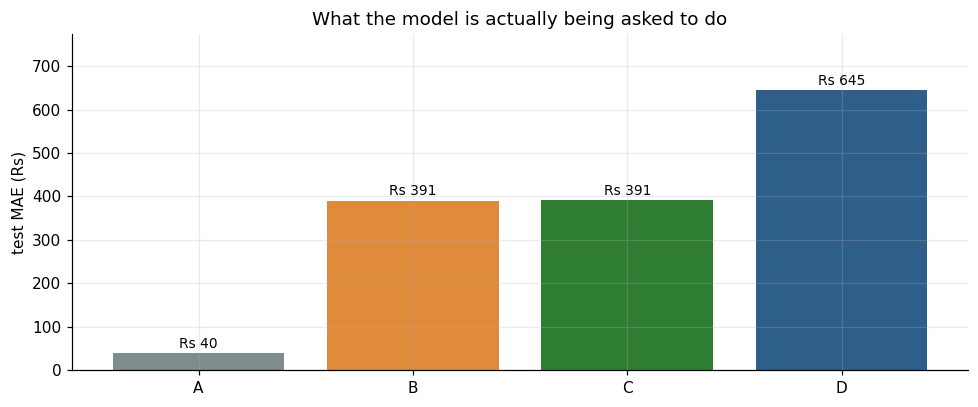

R2 drop from A to C: 0.0352
MAE goes from Rs 39.66 to Rs 391.16 - roughly ten times larger.


In [75]:
arch = TASK5['architecture_comparison']
rows = [
    ('A. fed true toll / parking / litres (Week 6)', arch['A_true_components']),
    ('B. chained, trained on true / served predicted', arch['B_mismatched_chain']),
    ('C. chained, trained on predictions (SHIPPED)',   arch['C_chained']),
    ('D. end-to-end, user inputs only',                arch['D_end_to_end']),
]
t = pd.DataFrame([{'architecture': n, 'model': v.get('model', '-'),
                   'test R2': v['r2'], 'RMSE Rs': v['rmse'], 'MAE Rs': v['mae']}
                  for n, v in rows])
display(t.style.format({'test R2': '{:.6f}', 'RMSE Rs': '{:.2f}',
                        'MAE Rs': '{:.2f}'}).hide(axis='index'))

fig, ax = plt.subplots(figsize=(9, 3.8))
labels_ = [n.split('.')[0] for n, _ in rows]
maes = [v['mae'] for _, v in rows]
bars = ax.bar(labels_, maes, color=['#7f8c8d', '#e08a3c', '#2e7d32', '#2e5f8a'])
ax.set_ylabel('test MAE (Rs)'); ax.set_title('What the model is actually being asked to do')
for b, v in zip(bars, maes):
    ax.text(b.get_x() + b.get_width()/2, v + 12, f'Rs {v:.0f}', ha='center', fontsize=9)
ax.set_ylim(0, max(maes) * 1.2)
plt.tight_layout(); plt.show()

print(f"R2 drop from A to C: {arch['r2_drop_A_to_C']:.4f}")
print(f"MAE goes from Rs {arch['A_true_components']['mae']:.2f} to "
      f"Rs {arch['C_chained']['mae']:.2f} - roughly ten times larger.")

### Reading the four rows

**A → C is the honest headline of this project.** R² falls 0.9997 → 0.9645 and MAE rises ₹40 →
₹391. That gap is not a regression in quality; it is the price of the model deriving its own
inputs instead of being handed them. **C is what a user actually receives, so C is what the app
now reports.**

**B vs C is the train/serve mismatch, and the measurement is a surprise.** B (trained on truth,
served predictions) scores MAE ₹390.56; C (trained on its own predictions) scores ₹391.16 —
B is *marginally better*. The mismatch cost essentially nothing here, and the reason is
specific: the sub-model errors are close to **zero-mean noise**, so the linear cost model's
coefficients are almost unchanged by retraining on them.

That is worth stating precisely rather than claiming a win. The chain-consistent model is still
the one shipped — it is the correct construction, and the property that rescues B (unbiased
sub-model errors) is a fact about this dataset, not something to rely on. But the honest report
is that **on this data the mismatch did not bite**, and pretending otherwise would be inventing
a result.

## 10.6 Where the remaining error comes from

"The honest model is worse" is not a finding. *"Toll and parking noise account for nearly all of
it"* is. Decomposing the test-set error into its sources:

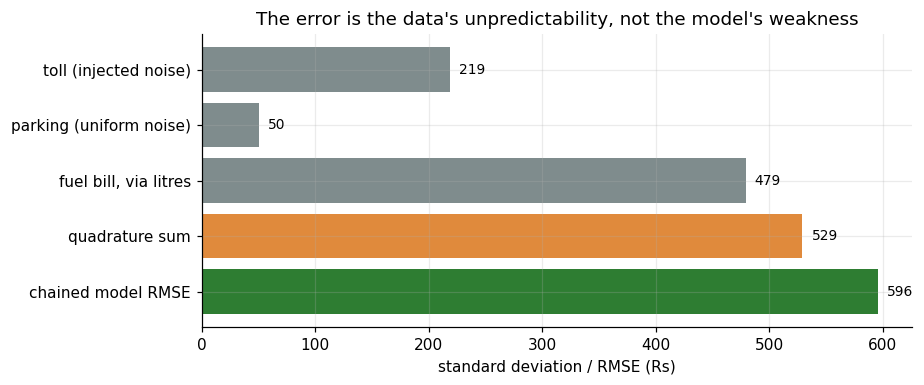

  distance error (km, not Rs)  : 44.42 km
  quadrature sum of cost terms : Rs 529.17
  chained model RMSE           : Rs 595.88
  ratio                        : 1.13


In [76]:
eb = PIPELINE['cost']['error_budget']
parts = [('toll (injected noise)', eb['toll_sd']),
         ('parking (uniform noise)', eb['parking_sd']),
         ('fuel bill, via litres', eb['fuel_bill_sd'])]

fig, ax = plt.subplots(figsize=(8.5, 3.6))
names_ = [p[0] for p in parts] + ['quadrature sum', 'chained model RMSE']
vals   = [p[1] for p in parts] + [eb['quadrature_sum'], eb['chained_rmse']]
cols   = ['#7f8c8d'] * 3 + ['#e08a3c', '#2e7d32']
b = ax.barh(names_, vals, color=cols)
ax.set_xlabel('standard deviation / RMSE (Rs)')
ax.set_title('The error is the data\'s unpredictability, not the model\'s weakness')
ax.invert_yaxis()
for bb, v in zip(b, vals):
    ax.text(v + 8, bb.get_y() + bb.get_height()/2, f'{v:.0f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(f"  distance error (km, not Rs)  : {eb['distance_sd_km']:.2f} km")
print(f"  quadrature sum of cost terms : Rs {eb['quadrature_sum']:.2f}")
print(f"  chained model RMSE           : Rs {eb['chained_rmse']:.2f}")
print(f"  ratio                        : {eb['chained_rmse'] / eb['quadrature_sum']:.2f}")

The quadrature sum of the irreducible terms is **₹529** against a model RMSE of **₹596** — a
ratio of 1.13. The two agree closely enough to say that the chain is near the floor this dataset
allows, and that the residual is **the data's unpredictability rather than the model's
weakness**.

The largest single term is the fuel bill (sd ₹479), and it is the one that could still be
improved: it inherits the distance error, so a better distance model propagates straight through
to a better cost estimate. Toll (₹219) and parking (₹50) cannot be improved by any model —
those are drawn from random distributions by construction.

There is a corresponding test in the suite (`test_metrics_error_budget_explains_the_remaining_error`)
asserting that ratio stays between 0.7 and 1.6, so a future regression in the chain shows up as
a failing test rather than a quietly worse number.

## 10.7 The end-to-end model — and where Week 6's lesson reverses

Architecture D removes even the chain. One model, fed **only** what a traveller could know:
two city names (as real latitude/longitude), vehicle, fuel type, departure hour, month,
passengers, mileage and fuel price. No distance, no toll, no litres, no parking.

It also re-runs Week 6's experiment in a harder setting. The true cost contains
`(distance / mileage) × fuel_price`, so two feature sets are compared: the raw inputs, and the
raw inputs plus `haversine/mileage` and `(haversine/mileage) × fuel_price`.

END-TO-END: features vs model complexity

  linear, base features        : R2 0.656346   MAE Rs 1118.68
  linear, + 2 engineered       : R2 0.676689   MAE Rs 1051.63
  RandomForest, base features  : R2 0.850960   MAE Rs 644.65

  MAE saved by two engineered columns : Rs 67.05
  MAE saved by switching to 300 trees : Rs 474.03
  VERDICT: the ensemble wins here - Week 6's claim does NOT generalise to this setup


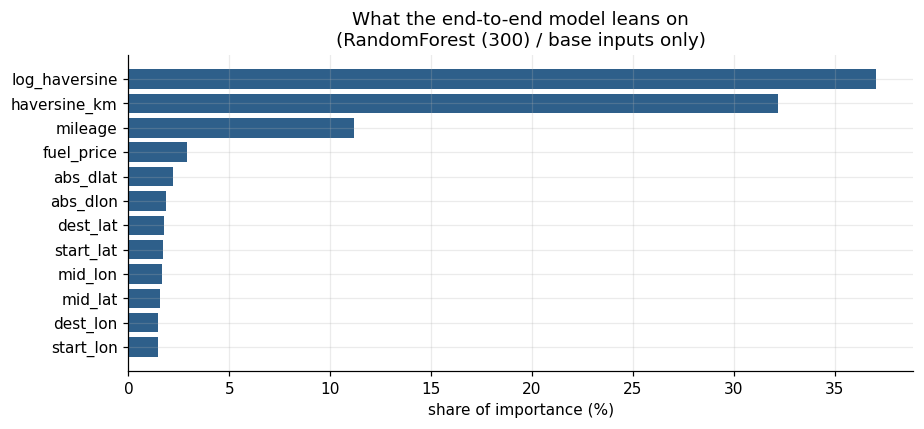

In [77]:
chk = E2E['week6_check']
print('END-TO-END: features vs model complexity\n')
print(f"  linear, base features        : R2 {chk['linear_base']['r2']:.6f}   "
      f"MAE Rs {chk['linear_base']['mae']:.2f}")
print(f"  linear, + 2 engineered       : R2 {chk['linear_engineered']['r2']:.6f}   "
      f"MAE Rs {chk['linear_engineered']['mae']:.2f}")
print(f"  RandomForest, base features  : R2 {chk['rf_base']['r2']:.6f}   "
      f"MAE Rs {chk['rf_base']['mae']:.2f}")
print(f"\n  MAE saved by two engineered columns : Rs {chk['mae_saved_by_features']:.2f}")
print(f"  MAE saved by switching to 300 trees : Rs {chk['mae_saved_by_model']:.2f}")
print(f"  VERDICT: {chk['verdict']}")

fi = E2E['feature_importance']
top = fi['ranked'][:12]
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.barh([f['feature'] for f in top][::-1], [f['share_pct'] for f in top][::-1],
        color='#2e5f8a')
ax.set_xlabel('share of importance (%)')
ax.set_title(f"What the end-to-end model leans on\n({fi['source']})")
plt.tight_layout(); plt.show()

### Week 6's claim does not generalise, and that is the interesting part

Week 6 argued — and demonstrated — that **domain understanding beat model complexity**: one
engineered feature beat two ensembles. End-to-end, the result **reverses**:

| | MAE saved |
|---|---|
| Two engineered columns | **₹67** |
| Switching to 300 trees | **₹474** |

The ensemble wins by a factor of seven. This is not a contradiction of Week 6, it is a boundary
condition on it, and the reason is identifiable. When distance was *given*, the only thing the
linear model could not express was a product — so handing it the product fixed the one gap.
End-to-end, the model must first infer road distance from four coordinates, and that is a
genuinely non-linear function of geography: coastlines, mountains, the Gulf of Khambhat. No
finite set of hand-made interaction terms captures it, and partitioning space is exactly what
trees do.

**Feature engineering beats model complexity when the missing structure is something you can
write down. When the missing structure is a map, it does not.**

### One trap in the importance ranking

`haversine` and its log carry **69%** of the prediction, mileage 11% — all sensible. But the
vehicle and fuel one-hots score **below 0.1%**, and it would be wrong to conclude vehicle type
does not matter.

Week 4 recovered a real per-km maintenance rate that differs by vehicle (Hatchback 0.5694,
Sedan 0.6943, SUV 0.8366 ₹/km) and Week 6 showed that dropping those columns made the app quote
an identical price for an SUV and a hatchback. The rate spread is about 0.27 ₹/km — roughly
₹108 on a 400 km trip — and end-to-end that signal sits *underneath* the toll and parking noise,
which is hundreds of rupees.

**The importance is low because the noise here is large, not because the effect is absent.**
It is precisely why the app serves the chained pipeline: pin distance and litres down first, and
the vehicle term becomes visible again. `passengers`, at 0.33%, is the genuine null — the
recovered formula has no passenger term at all, so anything above zero there is the forest
fitting noise.

## 10.8 What ships

`app.py` now loads `models/pipeline.joblib` and the five constants are gone. Live OSRM routing
is still preferred for distance — a real answer beats a predicted one — but the *fallback* is
now the fitted model rather than `haversine × 1.2355`.

Two constants remain, deliberately and labelled:

- `TRAFFIC_MIN_PER_KM` — travel **time**, which this project never modelled. It is not part of
  the cost target, so fitting it would be inventing scope.
- `MIN/MAX_TRAINED_KM` — the training range, used only to warn about extrapolation.

The change with the most user-visible consequence is not a model at all. `/api/predict` returns
`typical_error` beside every estimate, and that number used to be **₹39.66** — the MAE measured
with the true toll, parking and litres handed in. No real prediction could achieve it. It is now
**₹391.16**, the chained pipeline's own held-out error, and `/api/metrics` reports `served`
alongside `fed_true_components` with the gap between them named.

Quoting an unachievable error bar next to a prediction was the single least honest thing in the
project, and it is the thing this week actually fixed.

## Week 10 conclusion

| | |
|---|---|
| Constants removed from `app.py` | 5 |
| Sub-models fitted | 6 (1 trained on real observed data) |
| Sub-models that failed | 1 — parking, R² ≤ 0, reported as a negative result |
| Real data collected | 840 OSRM road distances |
| Distance model vs its constant | MAE 34.33 → 30.67 km (−10.7%) |
| Honest cost accuracy | **R² 0.9645, MAE ₹391** (was R² 0.9997, MAE ₹40 with inputs handed in) |
| Error budget | ₹529 of the ₹596 RMSE is irreducible noise in the data |
| Tests | 65, all passing |

### The three things this week established

1. **A near-perfect score is a question about the question.** R² 0.9997 was true and
   uninformative; the number that describes a user's prediction is 0.9645.
2. **A model that fails is a result.** Six model families could not predict parking, because
   nothing in the data predicts parking. Reporting that is worth more than tuning until it
   looks respectable.
3. **"Features beat complexity" has a boundary.** It held when the missing structure was a
   product you could write down. It reversed when the missing structure was a map.